# Diamond Creek ETF Arbitrage — Backtest v15


**v8:** Keeps the same v7 engine/data/costs, and adds a new weighting method that combines **backtest PnL/Gross** with **screener net decay signal** (`data/etf_screened_today.csv`), then applies a **shares-available capacity cap** so short ETF targets do not exceed a configurable fraction of available lendable shares.

**Dynamic target gross multiple:** **`V7_TARGET_LEV_START` → `V7_TARGET_LEV_END`** (default **4.5× → 5.0×** NAV) as a function of how many **post-start** candidate pairs have **non-trivial gross** on the book.

**Later cells:** After the equal-weight run, save NAVs + build **v8 combined weights**, then re-backtest with **`v8_pnl_decay_shares_weights.csv`**. Final section adds a historical **shares-available** analysis from `data/runs/*/etf_screened_today.csv`.


[Overview](#Diamond-Creek-ETF-Arbitrage--Backtest-v9) | [Setup](#Setup) | [Clear Street Live Borrow/Rebate](#Clear-Street-Live-BorrowRebate-Sandbox) | [Configuration](#Configuration) | [Universe](#Universe--v7-same-hardcoded-list-as-v6-from-DC_Universe_Map_Filteredxlsx)

## Setup


In [254]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests, time, ftplib, io, os
from datetime import datetime, timezone
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration


## v15 Override — Clear Street borrow rates + beta>1.5 universe

This override loads borrow rates from the Clear Street output in `data/runs/<run_day>/clearstreet/bulk_rates_one_by_one.csv`, filters the backtest universe to ETFs present in that file and with `Beta > 1.5`, then applies those borrow rates for sizing/backtest.

In [255]:
CFG = {
    "capital_usd":          5_000_000,
    "start_date":           "2025-10-07",
    "slippage_bps":         20,
    # Clear Street US equities low-touch baseline (35 mills/share).
    "clear_street_comm_per_share":  0.0035,
    "clear_street_comm_min":        0.00,
    "clear_street_comm_max_pct":    1.00,
    "fallback_borrow_rate": 0.0,
    # Clear Street financing assumptions from proposal:
    # debit = OBFR + 45 bps, cash credit / short rebate = OBFR - 40 bps,
    # negative benchmark/rate floored at 0, Actual/360 accrual.
    "margin_debit_spreads": [
        (float("inf"), 0.0045),
    ],
    "credit_spread":        -0.0040,
    "enable_short_credit_income": False,
    "financing_daycount":   360,
    "skip_ftp":             False,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,       # full position resize if portfolio gross drifts > 5% from target
    "weight_power":         1.15,       # mild convexity to lift return without aggressive concentration
    "mix_decay_weight":     0.40,       # balanced blend between realized PnL/Gross and decay signal
    "decay_weight_power":   1.05,       # slight emphasis on higher-quality decay names
    "max_dd_penalty_weight": 0.50,      # stronger explicit penalty for high drawdown names
    "max_dd_penalty_start": "2024-01-01", # focus DD penalty on 2024+ path quality
    "max_dd_penalty_recent_weight": 0.70, # heavier weight on recent-window DD vs full-history DD
    "position_concentration_power": 1.00, # neutral concentration tilt
    "short_avail_use_pct":  0.25,       # softer cap: can target up to 25% of reported shares_available
    "max_pair_weight_cap":  0.050,      # slightly higher cap to recover some upside
    "max_underlying_weight_cap": 0.11,  # mild relaxation for CAGR while keeping concentration bounded
    "missing_shares_cap":   0.02,       # strict fallback cap when shares_available is missing
    "cap_ramp_rebals":      4,          # slower ramp into constrained names
}

LEVERAGE_RUNS = [4.25]

V7_TARGET_LEV_START = 4   # incumbent day-0 sizing; floor for target multiple
V7_TARGET_LEV_END = 4.5    # modestly higher ceiling for CAGR once post-start pairs are on book

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x")
print("Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)")


Capital: $5,000,000  |  Start: 2025-10-07
Leverage: [4.25]  |  v8 target gross multiple: 4x → 4.5x
Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)


## PM margin — Diamond Creek sample book

Long/short equity book (~70 US names, mainly large caps and ETFs). **Source:** `data/backtest/PM Report Diamond Creek 20260326 CV.xlsx` → *Top Level Summary*.

PM notes (narrative): regulatory-style requirement lands near **$6.5MM**; **discretionary** add-on tied to crypto proxies (BITU, BITX, ETHA, ETHT, ETHU, IBIT, SOEZ); **concentration** add-on on largest names (e.g. NVDA, TSLA); small **liquidity** add-on (SOEZ). **PM/GMV** in the file is *Effective margin requirement ÷ GMV* (~17%).

The next cell loads the spreadsheet and estimates **margin excess** if gross exposure were raised to **4.5× equity** (same equity, higher GMV), by applying the file’s **MR/GMV** ratio to the new gross (equivalent to scaling today’s effective margin **linearly with GMV** when the report is internally consistent).


## Universe



In [256]:
# ---- Diamond v16 migration: screener-driven universe, no Bucket 3 ----
# Universe comes entirely from etf_screened_today.csv; no hardcoded candidate tuples.
_screen_paths = [
    Path(r"C:/Users/werdn/Documents/Investing/Diamond-Creek-Quant/data/etf_screened_today.csv"),
    Path("../data/etf_screened_today.csv"),
    Path("data/etf_screened_today.csv"),
]
SCREENED_PATH_DCQ = next((p.resolve() for p in _screen_paths if p.exists()), None)
if SCREENED_PATH_DCQ is None:
    raise FileNotFoundError("Could not find etf_screened_today.csv in Diamond-Creek-Quant/data, ../data, or data")

SCREENED_DCQ = pd.read_csv(SCREENED_PATH_DCQ)
SCREENED_DCQ.columns = [str(c).strip() for c in SCREENED_DCQ.columns]
_required_screen_cols = {"ETF", "Underlying", "Beta"}
_missing_screen_cols = _required_screen_cols - set(SCREENED_DCQ.columns)
if _missing_screen_cols:
    raise KeyError(f"{SCREENED_PATH_DCQ} is missing required columns: {sorted(_missing_screen_cols)}")

SCREENED_DCQ["ETF"] = SCREENED_DCQ["ETF"].map(norm_sym)
SCREENED_DCQ["Underlying"] = SCREENED_DCQ["Underlying"].map(norm_sym)
SCREENED_DCQ["Beta"] = pd.to_numeric(SCREENED_DCQ["Beta"], errors="coerce")
SCREENED_DCQ = SCREENED_DCQ[
    SCREENED_DCQ["ETF"].ne("")
    & SCREENED_DCQ["Underlying"].ne("")
    & SCREENED_DCQ["Beta"].notna()
].copy()
SCREENED_DCQ = SCREENED_DCQ[SCREENED_DCQ["ETF"].ne("KOLD")].copy()

# Use the stored Diamond-Creek-Quant average borrow series as the canonical borrow input.
# DCQ rows use short_favorable_positive, while this notebook/GTP mirror use positive = borrow cost.
_borrow_avg_signed = pd.to_numeric(SCREENED_DCQ.get("borrow_avg_annual"), errors="coerce")
_borrow_current_signed = pd.to_numeric(SCREENED_DCQ.get("borrow_current"), errors="coerce")
_borrow_fee_signed = pd.to_numeric(SCREENED_DCQ.get("borrow_fee_annual"), errors="coerce")
_borrow_signed = _borrow_avg_signed.combine_first(_borrow_current_signed).combine_first(_borrow_fee_signed)
_sign_convention = SCREENED_DCQ.get("borrow_sign_convention", pd.Series("", index=SCREENED_DCQ.index)).astype(str).str.lower()
_short_fav = _sign_convention.eq("short_favorable_positive")
_borrow_cost = _borrow_signed.where(~_short_fav, -_borrow_signed)
SCREENED_DCQ["dcq_borrow_avg_annual"] = _borrow_avg_signed
SCREENED_DCQ["dcq_borrow_avg_cost_annual"] = _borrow_cost
SCREENED_DCQ["borrow_avg_annual"] = _borrow_cost
SCREENED_DCQ["borrow_current"] = _borrow_cost
SCREENED_DCQ["borrow_fee_annual"] = _borrow_cost
SCREENED_DCQ["borrow_current_raw_annual"] = _borrow_cost
DCQ_AVG_BORROW_MAP = {
    str(e): float(b)
    for e, b in zip(SCREENED_DCQ["ETF"], SCREENED_DCQ["dcq_borrow_avg_cost_annual"])
    if pd.notna(b) and np.isfinite(float(b))
}

# Keep DCQ borrow, but fill capacity fields from the local screener when DCQ has blanks.
_capacity_paths = [Path("../data/etf_screened_today.csv"), Path("data/etf_screened_today.csv")]
_capacity_path = next((p.resolve() for p in _capacity_paths if p.exists()), None)
if _capacity_path is not None:
    _cap = pd.read_csv(_capacity_path)
    _cap.columns = [str(c).strip() for c in _cap.columns]
    if {"ETF", "Underlying"}.issubset(_cap.columns):
        _cap["ETF"] = _cap["ETF"].map(norm_sym)
        _cap["Underlying"] = _cap["Underlying"].map(norm_sym)
        _cap = _cap.drop_duplicates(subset=["ETF", "Underlying"], keep="first")
        _fill_cols = [
            "shares_available",
            "borrow_price_ref",
            "aum_usd",
            "etf_aum_usd",
            "AUM",
            "AUM_M",
            "median_daily_volume_shares",
            "median_volume_shares_60d",
            "adv_median_shares",
            "adv_shares_median",
            "median_volume_shares",
        ]
        _fill_cols = [c for c in _fill_cols if c in _cap.columns]
        if _fill_cols:
            SCREENED_DCQ = SCREENED_DCQ.merge(
                _cap[["ETF", "Underlying", *_fill_cols]].rename(columns={c: f"_cap_{c}" for c in _fill_cols}),
                on=["ETF", "Underlying"],
                how="left",
            )
            for _c in _fill_cols:
                _src = f"_cap_{_c}"
                if _c not in SCREENED_DCQ.columns:
                    SCREENED_DCQ[_c] = SCREENED_DCQ[_src]
                else:
                    _cur = pd.to_numeric(SCREENED_DCQ[_c], errors="coerce")
                    _donor = pd.to_numeric(SCREENED_DCQ[_src], errors="coerce")
                    SCREENED_DCQ[_c] = _cur.where(_cur.notna() & (_cur > 0), _donor)
                SCREENED_DCQ.drop(columns=[_src], inplace=True)
            print(f"[DCQ] Capacity fields filled from local screener: {_capacity_path}")

# Prevent legacy etfs2/sample-book maps from taking precedence downstream.
SAMPLE_BOOK_BORROW_MAP = {}

SCREENED_DCQ = SCREENED_DCQ.drop_duplicates(subset=["ETF", "Underlying"], keep="first").reset_index(drop=True)

CANDIDATES = [
    (str(r.ETF), str(r.Underlying), float(r.Beta))
    for r in SCREENED_DCQ[["ETF", "Underlying", "Beta"]].itertuples(index=False)
]
EXTRA_ETFS = set()
WHITELIST_ETFS = set(
    SCREENED_DCQ.loc[SCREENED_DCQ.get("is_yieldboost", False).fillna(False).astype(bool), "ETF"].astype(str)
)
BUCKET3_CANDIDATES = []
BUCKET3_ETFS = set()
BUCKET3_UNDERLYINGS = set()
B3_ETFS = frozenset()
B3_KEYS = frozenset()
B3_INC_KEYS = frozenset()
USE_SAMPLE_BOOK_ONLY = False
V15_ETFS2_OVERRIDE_ACTIVE = False
V13_ETFS2_OVERRIDE_ACTIVE = False

print(f"[DCQ] Screener universe source: {SCREENED_PATH_DCQ}")
print(f"[DCQ] Candidate pairs from screener: {len(CANDIDATES)} | KOLD excluded: {'KOLD' not in set(SCREENED_DCQ['ETF'])}")
print(f"[DCQ] Average borrow loaded from stored DCQ screener: {len(DCQ_AVG_BORROW_MAP)}/{len(SCREENED_DCQ)} ETFs")
print("[DCQ] Bucket 3 disabled; inverse LETFs remain eligible for Bucket 4 sizing criteria.")


[DCQ] Capacity fields filled from local screener: C:\Users\werdn\Documents\Investing\ls-algo\data\etf_screened_today.csv
[DCQ] Screener universe source: C:\Users\werdn\Documents\Investing\Diamond-Creek-Quant\data\etf_screened_today.csv
[DCQ] Candidate pairs from screener: 391 | KOLD excluded: True
[DCQ] Average borrow loaded from stored DCQ screener: 359/391 ETFs
[DCQ] Bucket 3 disabled; inverse LETFs remain eligible for Bucket 4 sizing criteria.


In [257]:
# ---- Legacy sample-book universe restriction disabled ----
# The Diamond v16 migration uses the full screener-driven universe from the prior cell.
USE_SAMPLE_BOOK_ONLY = False
print(f"[DCQ] Full screener universe active: {len(CANDIDATES)} pairs")


[DCQ] Full screener universe active: 391 pairs


## Data — Borrow Rates, Prices, Pair Selection


In [258]:
# ---- Borrow rates (historical average first, FTP/cache fallback) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]
BORROW_CACHE = Path("data/borrow_cache.csv")

# Resolve runs path robustly across notebook cwd variants.
runs_candidates = [
    Path("data/runs"),
    Path("../data/runs"),
    Path.cwd() / "data/runs",
    Path.cwd() / "../data/runs",
    Path.cwd().parent / "data/runs",
]
RUNS_ROOT = next((p.resolve() for p in runs_candidates if p.exists()), None)
if RUNS_ROOT is None:
    RUNS_ROOT = Path("data/runs")

# Build consolidated historical panel (borrow + shares) from run snapshots.
def _trimmed_mean_drop2(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
    if len(x) <= 4:
        return float(x.mean()) if len(x) else np.nan
    return float(x.iloc[2:-2].mean())


def _norm_col(c: str) -> str:
    return "".join(ch for ch in str(c).lower().strip() if ch.isalnum())


def _pick_col(cols: list[str], exact_norm: list[str], fuzzy_contains: list[str] | None = None) -> str | None:
    norm_to_orig = {_norm_col(c): c for c in cols}
    for k in exact_norm:
        if k in norm_to_orig:
            return norm_to_orig[k]
    if fuzzy_contains:
        for c in cols:
            nc = _norm_col(c)
            if all(tok in nc for tok in fuzzy_contains):
                return c
    return None


# Prefer etf_screened_today for a date, but still use proposed_trades to fill missing fields.
def _historical_snapshot_files(root: Path) -> list[tuple[pd.Timestamp, Path, int]]:
    out = []
    for d in sorted(root.glob("*")):
        if not d.is_dir():
            continue
        ds = pd.to_datetime(d.name, errors="coerce")
        if pd.isna(ds):
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            out.append((ds, f_screen, 0))
        if f_trades.exists():
            out.append((ds, f_trades, 1))

    # Include current latest screener/proposed files if present.
    extra = [
        (Path("data/etf_screened_today.csv"), 2),
        (Path("../data/etf_screened_today.csv"), 2),
        (Path("data/proposed_trades.csv"), 3),
        (Path("../data/proposed_trades.csv"), 3),
    ]
    for p, rank in extra:
        if p.exists():
            dt = pd.to_datetime(p.stat().st_mtime, unit="s", errors="coerce")
            out.append((dt, p, rank))
    return out


def _extract_snapshot_rows(ds: pd.Timestamp, fp: Path, src_rank: int) -> pd.DataFrame:
    try:
        d = pd.read_csv(fp)
    except Exception:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])
    if d.empty:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    cols = list(d.columns)
    etf_col = _pick_col(cols, ["etf", "ticker", "symbol", "sym"], None)
    if etf_col is None:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    borrow_col = _pick_col(
        cols,
        [
            "borrownetannual",
            "borrowcurrent",
            "borrowfeeannual",
            "borrowrate",
            "feeborrow",
            "borrowfee",
            "shortborrowrate",
            "shortfee",
        ],
        ["borrow"],
    )

    shares_col = _pick_col(
        cols,
        [
            "sharesavailable",
            "sharesavail",
            "availableshares",
            "sharesavailableforshort",
            "shortsharesavailable",
        ],
        ["share", "avail"],
    )

    out = pd.DataFrame()
    out["date"] = [ds] * len(d)
    out["etf"] = d[etf_col].astype(str).str.upper().str.strip()
    out["borrow_rate"] = pd.to_numeric(d[borrow_col], errors="coerce") if borrow_col is not None else np.nan
    out["shares_available"] = pd.to_numeric(d[shares_col], errors="coerce") if shares_col is not None else np.nan
    out["src_rank"] = src_rank
    out["src_file"] = str(fp)
    out = out[out["etf"].ne("")].copy()
    return out[["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"]]


hist_raw = []
for ds, fp, src_rank in _historical_snapshot_files(RUNS_ROOT):
    rows = _extract_snapshot_rows(ds, fp, src_rank)
    if not rows.empty:
        hist_raw.append(rows)

if hist_raw:
    hist_raw_df = pd.concat(hist_raw, ignore_index=True)

    def _first_valid(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna()
        return float(x.iloc[0]) if len(x) else np.nan

    # Per date/ticker, keep first valid field with file priority: screen -> proposed_trades -> local latest files.
    hist_raw_df = hist_raw_df.sort_values(["date", "etf", "src_rank"]).reset_index(drop=True)
    HIST_SNAPSHOT_PANEL = (
        hist_raw_df.groupby(["date", "etf"], as_index=False)
        .agg(
            borrow_rate=("borrow_rate", _first_valid),
            shares_available=("shares_available", _first_valid),
        )
        .sort_values(["date", "etf"])
        .reset_index(drop=True)
    )

    # Maps consumed by older downstream cells.
    hist_avg_map = HIST_SNAPSHOT_PANEL.groupby("etf")["borrow_rate"].apply(_trimmed_mean_drop2).to_dict()
    HIST_BORROW_AVG_MAP = hist_avg_map
    HIST_SHARES_AVG_MAP = HIST_SNAPSHOT_PANEL.groupby("etf")["shares_available"].mean().to_dict()

    hist_covered = sum(1 for e in all_etf_syms if e in hist_avg_map and pd.notna(hist_avg_map[e]))
    shares_covered = sum(1 for e in all_etf_syms if e in HIST_SHARES_AVG_MAP and pd.notna(HIST_SHARES_AVG_MAP[e]))
    print(
        f"[HIST] files={hist_raw_df['date'].nunique()} dates | borrow tickers={hist_covered}/{len(all_etf_syms)} | "
        f"shares tickers={shares_covered}/{len(all_etf_syms)}"
    )
else:
    HIST_SNAPSHOT_PANEL = pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available"])
    HIST_BORROW_AVG_MAP = {}
    HIST_SHARES_AVG_MAP = {}
    hist_avg_map = {}
    print("[HIST] no usable run files found")

# Build Clear Street current map (no IBKR FTP in this notebook).
cs_map = {}
cs_shares_map = {}
cs_cov_path = Path("data/borrow_coverage_etf_screened_today.csv")
if not cs_cov_path.exists():
    cs_cov_path = Path("../data/borrow_coverage_etf_screened_today.csv")

if cs_cov_path.exists():
    cs_cov = pd.read_csv(cs_cov_path)
    if "symbol" in cs_cov.columns:
        cs_cov["symbol"] = cs_cov["symbol"].astype(str).str.upper().str.strip()
        if "borrow_fee_annual_final" in cs_cov.columns:
            v = pd.to_numeric(cs_cov["borrow_fee_annual_final"], errors="coerce")
            cs_map = {s: float(x) for s, x in zip(cs_cov["symbol"], v) if pd.notna(x)}
        if "shares_available_final" in cs_cov.columns:
            s = pd.to_numeric(cs_cov["shares_available_final"], errors="coerce")
            cs_shares_map = {sym: float(x) for sym, x in zip(cs_cov["symbol"], s) if pd.notna(x)}

    cs_cov_borrow = sum(1 for e in all_etf_syms if e in cs_map)
    cs_cov_shares = sum(1 for e in all_etf_syms if e in cs_shares_map)
    print(f"[CS] current borrow available for {cs_cov_borrow}/{len(all_etf_syms)} tickers")
    print(f"[CS] current shares available for {cs_cov_shares}/{len(all_etf_syms)} tickers")
else:
    print("[CS] borrow_coverage_etf_screened_today.csv not found; run the top Clear Street cell first.")

# Prefer live Clear Street shares where available.
if cs_shares_map:
    HIST_SHARES_AVG_MAP = {**HIST_SHARES_AVG_MAP, **cs_shares_map}

# Final borrow map used by backtest.
# For this Diamond v16 migration, prefer the stored Diamond-Creek-Quant average borrow rate.
BORROW_MAP = {}
src_dcq = src_hist = src_cs = src_flat = 0
_dcq_avg_map = {
    str(k).upper().strip().replace(".", "-"): float(v)
    for k, v in (globals().get("DCQ_AVG_BORROW_MAP", {}) or {}).items()
    if pd.notna(v) and np.isfinite(float(v))
}
for e in all_etf_syms:
    ee = str(e).upper().strip().replace(".", "-")
    if ee in _dcq_avg_map:
        BORROW_MAP[ee] = float(_dcq_avg_map[ee])
        src_dcq += 1
    elif ee in hist_avg_map and pd.notna(hist_avg_map[ee]):
        BORROW_MAP[ee] = float(hist_avg_map[ee])
        src_hist += 1
    elif ee in cs_map and pd.notna(cs_map[ee]):
        BORROW_MAP[ee] = float(cs_map[ee])
        src_cs += 1
    else:
        BORROW_MAP[ee] = CFG["fallback_borrow_rate"]
        src_flat += 1
print(
    f"[BORROW] source mix -> dcq_avg: {src_dcq}, hist_avg: {src_hist}, "
    f"clearstreet: {src_cs}, flat: {src_flat}"
)


[HIST] files=2 dates | borrow tickers=355/391 | shares tickers=389/391
[CS] current borrow available for 1/391 tickers
[CS] current shares available for 1/391 tickers
[BORROW] source mix -> dcq_avg: 359, hist_avg: 14, clearstreet: 0, flat: 18


In [259]:
# ---- Total-return prices ----
import yfinance as yf

# Manual split overrides for outlier tickers/dates (applied in raw-close path).
# Example: reverse split 1-for-10 => factor 0.1 on split date.
MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {
        # For this feed representation, 10.0 neutralizes the reverse-split discontinuity.
        "2026-01-26": 10.0,
    },
    "EOSU": {
        # 1-for-25 reverse split (effective 2026-04-08): use feed-space factor.
        "2026-04-08": 25.0,
    },
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()

        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw_path = tkr in manual_splits

        # Prefer Yahoo adjusted close unless we explicitly need manual split overrides.
        if (not force_raw_path) and ("Adj Close" in df.columns) and (df["Adj Close"].notna().sum() > 20):
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()

        close = df["Close"].astype(float)
        divs = (
            df["Dividends"].fillna(0).astype(float)
            if "Dividends" in df.columns
            else pd.Series(0.0, index=close.index)
        )
        splits = (
            df["Stock Splits"].replace(0, 1).fillna(1).astype(float)
            if "Stock Splits" in df.columns
            else pd.Series(1.0, index=close.index)
        )

        # Manual split overrides for outlier names/dates.
        # Apply on exact date, or nearest next trading day within 3 calendar days.
        if tkr in manual_splits:
            applied = []
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]

                if apply_ts is None:
                    print(f"[split-override] {tkr} {ts.date()} not applied (date not found)")
                    continue

                f = float(factor)
                old_factor = float(splits.loc[apply_ts])

                # Back-adjust all history before split day to post-split basis.
                # Here, `factor` is interpreted as the pre-split back-adjust multiplier.
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f

                # Neutralize split jump on event day because history is already back-adjusted.
                splits.loc[apply_ts] = 1.0

                applied.append((ts, apply_ts, old_factor, f))

            if applied:
                for ts, apply_ts, old_factor, f in applied:
                    print(
                        f"[split-override] {tkr} requested {ts.date()} applied {apply_ts.date()} "
                        f"back-adjust x{f:g}, split-factor {old_factor:g} -> 1 (event-day neutralized)"
                    )
            else:
                print(f"[split-override] {tkr} had no applied overrides")

        # Daily total-return factor with split and dividend handling.
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 20 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")
if globals().get("MANUAL_SPLIT_OVERRIDES"):
    print("Manual split overrides active:")
    for _t, _m in MANUAL_SPLIT_OVERRIDES.items():
        for _d, _f in _m.items():
            print(f"  {_t} {_d} factor={_f}")

# ---- Manual bad-print repairs (targeted) ----
# Modes:
# - "interpolate": one-day midpoint interpolation from neighbors
# - {"mode": "interpolate_window", "dates": [...]}: replace listed dates by
#   linear interpolation anchored by nearest clean observations outside the window.
# - {"mode": "beta_from_underlying", "underlying": "SMR", "beta": 2.058}:
#   reprice ETF on that date from underlying return and beta.
# Keep empty by default; leave hook in place for non-split bad ticks if ever needed.
MANUAL_TR_PRICE_FIXES = {}


def _apply_manual_price_fixes(prices_map, fixes):
    applied = []

    for ticker, dmap in fixes.items():
        s = prices_map.get(ticker)
        if s is None or s.empty:
            continue
        s = s.sort_index().copy()

        # First handle explicit windows.
        for _, spec in dmap.items():
            if not isinstance(spec, dict) or spec.get("mode") != "interpolate_window":
                continue

            dates = [pd.Timestamp(x) for x in spec.get("dates", [])]
            dates = sorted([d for d in dates if d in s.index])
            if not dates:
                continue

            left_idx = s.index[s.index < dates[0]]
            right_idx = s.index[s.index > dates[-1]]
            if left_idx.empty or right_idx.empty:
                continue

            left_t = left_idx[-1]
            right_t = right_idx[0]
            y0 = float(s.loc[left_t])
            y1 = float(s.loc[right_t])
            x0 = float(left_t.value)
            x1 = float(right_t.value)
            if x1 <= x0:
                continue

            for ts in dates:
                old = float(s.loc[ts])
                x = float(ts.value)
                w = (x - x0) / (x1 - x0)
                new = y0 + w * (y1 - y0)
                s.loc[ts] = new
                applied.append((ticker, ts, old, float(new), "interpolate_window"))

        # Then handle single-date fixes.
        for ds, mode in dmap.items():
            ts = pd.Timestamp(ds)
            if ts not in s.index:
                continue

            # Dict mode for date-specific advanced fixes.
            if isinstance(mode, dict):
                m = mode.get("mode")
                if m == "beta_from_underlying":
                    und = str(mode.get("underlying", "")).upper()
                    beta = float(mode.get("beta", 1.0))
                    su = prices_map.get(und)
                    prev_idx = s.index[s.index < ts]
                    if su is None or su.empty or prev_idx.empty:
                        continue

                    prev_t = prev_idx[-1]
                    p_u_t = float(su.asof(ts))
                    p_u_prev = float(su.asof(prev_t))
                    p_e_prev = float(s.loc[prev_t])
                    if p_u_prev <= 0 or p_e_prev <= 0:
                        continue

                    r_u = p_u_t / p_u_prev - 1.0
                    new = max(1e-6, p_e_prev * (1.0 + beta * r_u))
                    old = float(s.loc[ts])
                    s.loc[ts] = new
                    applied.append((ticker, ts, old, float(new), f"beta_from_{und}"))
                continue

            old = float(s.loc[ts])
            prev = s[s.index < ts]
            nxt = s[s.index > ts]

            if mode == "interpolate" and not prev.empty and not nxt.empty:
                new = float((prev.iloc[-1] + nxt.iloc[0]) / 2.0)
            elif not prev.empty:
                new = float(prev.iloc[-1])
            elif not nxt.empty:
                new = float(nxt.iloc[0])
            else:
                continue

            s.loc[ts] = new
            applied.append((ticker, ts, old, new, mode))

        prices_map[ticker] = s

    if applied:
        print("Applied manual price fixes:")
        for ticker, ts, old, new, mode in applied:
            print(f"  {ticker} {ts.date()} [{mode}] {old:,.4f} -> {new:,.4f}")
    else:
        print("No manual price fixes applied.")


_apply_manual_price_fixes(PRICES, MANUAL_TR_PRICE_FIXES)

# Quick sanity check: max absolute Jan-2026 daily return.
for _sym in ["SMR", "SMUP"]:
    _s = PRICES.get(_sym)
    if _s is None or _s.empty:
        continue
    _jan = _s[(_s.index >= pd.Timestamp("2026-01-01")) & (_s.index < pd.Timestamp("2026-02-01"))]
    _r = _jan.pct_change().dropna()
    if not _r.empty:
        _d = _r.abs().idxmax()
        print(f"{_sym} largest Jan return: {_d.date()} | {_r.loc[_d]:.2%}")

# ---- OBFR benchmark (fallback to Fed Funds) ----
try:
    obfr_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=OBFR"
    obfr_df = pd.read_csv(obfr_url)
    obfr_df.columns = [str(c).strip() for c in obfr_df.columns]
    date_col = "DATE" if "DATE" in obfr_df.columns else ("observation_date" if "observation_date" in obfr_df.columns else None)
    if date_col is None or "OBFR" not in obfr_df.columns:
        raise KeyError(f"Unexpected OBFR columns: {list(obfr_df.columns)}")

    obfr_df["date"] = pd.to_datetime(obfr_df[date_col], errors="coerce")
    obfr_df["rate"] = pd.to_numeric(obfr_df["OBFR"], errors="coerce")
    obfr_df = obfr_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (obfr_df["rate"] / 100).astype(float)
    print(f"OBFR: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
except Exception as e_obfr:
    print(f"OBFR fetch failed ({e_obfr}), trying DFF fallback")
    try:
        dff_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF"
        ff_df = pd.read_csv(dff_url)
        ff_df.columns = [str(c).strip() for c in ff_df.columns]
        date_col = "DATE" if "DATE" in ff_df.columns else ("observation_date" if "observation_date" in ff_df.columns else None)
        if date_col is None or "DFF" not in ff_df.columns:
            raise KeyError(f"Unexpected DFF columns: {list(ff_df.columns)}")

        ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
        ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
        ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
        FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
        print(f"DFF fallback: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
    except Exception as e_dff:
        print(f"FRED failed ({e_dff}), using static fallback")
        fomc = [(pd.Timestamp("2022-12-14"), 0.0433), (pd.Timestamp("2023-02-01"), 0.0458),
                (pd.Timestamp("2023-03-22"), 0.0483), (pd.Timestamp("2023-05-03"), 0.0508),
                (pd.Timestamp("2023-07-26"), 0.0533), (pd.Timestamp("2024-09-18"), 0.0483),
                (pd.Timestamp("2024-11-07"), 0.0458), (pd.Timestamp("2024-12-18"), 0.0433),
                (pd.Timestamp("2025-01-29"), 0.0433)]
        FED_FUNDS_DAILY = pd.Series({d: r for d, r in fomc}).sort_index()


  20/610 [2s]
  40/610 [3s]
  60/610 [4s]
  80/610 [5s]
  100/610 [6s]
  120/610 [6s]
  140/610 [7s]
  160/610 [7s]
  180/610 [9s]
  200/610 [9s]
  220/610 [10s]
  240/610 [10s]
  260/610 [11s]
  280/610 [12s]
  300/610 [13s]
  320/610 [14s]
  340/610 [14s]
  360/610 [15s]
  380/610 [16s]
  400/610 [16s]
  420/610 [17s]
  440/610 [17s]
  460/610 [18s]
  480/610 [19s]
  500/610 [19s]
  520/610 [20s]
  540/610 [21s]
  560/610 [21s]
  580/610 [22s]
  600/610 [23s]
Got 589/610 [23.5s]
Manual split overrides active:
  SMUP 2026-01-26 factor=10.0
  EOSU 2026-04-08 factor=25.0
No manual price fixes applied.
SMR largest Jan return: 2026-01-05 | 15.14%
OBFR: 2559 daily obs (observation_date)


In [260]:
# ---- Inception dates + full universe (post–start_date listings join when data exists) ----
if "CFG" not in globals():
    if "cfg" in globals() and isinstance(cfg, dict):
        CFG = cfg
    else:
        raise RuntimeError("CFG is not defined in this kernel. Run the 'Configuration' cell first, then rerun this cell.")

start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf)
    s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        first = max(s_e.index[0], s_u.index[0])
        INCEPTION[(etf, und)] = first

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])

RAMP_WEEKS = 4  # weekly rebalances to scale new listings from 1/RAMP_WEEKS → full weight

n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(f"Pairs with overlapping price data: {len(INCEPTION)} / {len(CANDIDATES)}")
print(f"Full UNIVERSE: {len(UNIVERSE)} pairs (v7: incremental engine)")
print(f"Tradeable at {CFG['start_date']}: {n_at_start} pairs | RAMP_WEEKS={RAMP_WEEKS}")
print()
for i, (e, u, b) in enumerate(UNIVERSE, 1):
    inc = INCEPTION[(e, u)].strftime("%Y-%m-%d")
    tag = "  [post-start]" if INCEPTION[(e, u)] > start_ts else ""
    print(f"  {i:3d}  {e:5s}  {u:5s}  {b:.3f}  {inc}{tag}")


Pairs with overlapping price data: 370 / 391
Full UNIVERSE: 370 pairs (v7: incremental engine)
Tradeable at 2025-10-07: 233 pairs | RAMP_WEEKS=4

    1  SDS    SPY    -1.993  2006-07-13
    2  QID    QQQ    -1.997  2006-07-13
    3  DXD    DIA    -2.002  2006-07-13
    4  TWM    IWM    -2.001  2007-01-25
    5  SKF    XLF    -1.999  2007-02-01
    6  DUG    XLE    -1.990  2007-02-01
    7  REW    XLK    -2.003  2007-02-02
    8  EWV    EWJ    -2.008  2007-11-08
    9  TBT    TLT    -1.997  2008-05-22
   10  SPXL   SPY    2.387  2008-11-05
   11  ERX    XLE    2.003  2008-11-19
   12  SPXS   SPY    -2.997  2008-11-19
   13  TZA    IWM    -2.997  2008-11-19
   14  FAZ    XLF    -2.994  2008-11-19
   15  SCO    USO    -1.742  2008-11-25
   16  ZSL    SLV    -2.027  2008-12-03
   17  TECS   XLK    -2.996  2008-12-30
   18  TMV    TLT    -2.990  2009-04-16
   19  SPXU   SPY    -2.994  2009-06-25
   20  YINN   FXI    2.378  2009-12-03
   21  TQQQ   QQQ    2.388  2010-02-11
   22  URTY   IWM 

In [261]:
# ---- Diamond v16 migration: selected B1/B2/B4 sizing config ----
import copy
import importlib
import pickle
import sys
import yaml


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "config" / "strategy_config.yml").exists() and (p / "scripts" / "gtp_sizing_mirror.py").exists():
            return p
    raise FileNotFoundError("Could not find repo root with config/strategy_config.yml and scripts/gtp_sizing_mirror.py")


REPO_ROOT_DCQ = _find_repo_root()
if str(REPO_ROOT_DCQ) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT_DCQ))

with open(REPO_ROOT_DCQ / "config" / "strategy_config.yml", "r", encoding="utf-8") as f:
    STRATEGY_CFG_DCQ = yaml.safe_load(f) or {}
strategy_cfg = STRATEGY_CFG_DCQ.setdefault("strategy", {})
sleeves_cfg = STRATEGY_CFG_DCQ.setdefault("portfolio", {}).setdefault("sleeves", {})

# Notebook-local sleeve targets for this Diamond backtest.
DCQ_BUCKET_TARGETS = {
    "core_leveraged": 0.75,
    "whitelist_stock": 0.0,
    "inverse_decay_bucket4": 0.25,
}

EXP_DCQ = {
    "capital_usd": float(CFG["capital_usd"]),
    "initial_capital_usd": float(CFG["capital_usd"]),
    "gross_leverage": float(V7_TARGET_LEV_END),
    "rebalance_freq": "W-FRI",
    "rebalance_freq_bucket_4": "W-FRI",
    "use_covariance": True,
    "b4_dynamic_hedge": True,
    "b4_lab_pf_initial": float(CFG["capital_usd"]),
    "v6_b4_cache_path": str(REPO_ROOT_DCQ / "notebooks" / "v6_b4_gtp_cache.pkl"),
    "b4_weights_use_ibkr_uvix_borrow": True,
}
EXP = EXP_DCQ

import generate_trade_plan as _gtp_live
import scripts.gtp_sizing_mirror as _gsm_live
import scripts.v6_b4_pf_weights as _v6_b4_pf_mod
import scripts.bucket4_dynamic_bt as _b4dyn_live
import scripts.bucket4_tail_portfolio as _b4tp_live

importlib.reload(_gtp_live)
importlib.reload(_gsm_live)
importlib.reload(_v6_b4_pf_mod)
importlib.reload(_b4dyn_live)
importlib.reload(_b4tp_live)

from scripts.gtp_sizing_mirror import mirror_generate_trade_plan_sizing
from scripts.v6_b4_pf_weights import V6PfParams, compute_v6_b4_pf_weight_dict
from scripts.bucket4_tail_portfolio import aggregate_tail_risk_weighted_portfolio

SLEEVE_BY_BUCKET_DCQ = {1: "core_leveraged", 2: "whitelist_stock", 4: "inverse_decay_bucket4"}
_GROSS_CAPS_PS = (strategy_cfg.get("gross_sizing_caps") or {}).get("per_sleeve") or {}
_B1_CAPS = _GROSS_CAPS_PS.get("core_leveraged") or {}
_B2_CAPS = _GROSS_CAPS_PS.get("whitelist_stock") or {}
_B4_CAPS = _GROSS_CAPS_PS.get("inverse_decay_bucket4") or {}

SELECTED_B1_PARAMS = {
    "min_net_edge": 0.06,
    "borrow_aversion": 0.35,
    "eq_blend": 0.0,
    "score_concavity_p": 2.0,
    "cov_penalty": 0.85,
    "max_name_weight": float(_B1_CAPS.get("max_pair_weight", 0.10)),
    "max_underlying_weight": float(_B1_CAPS.get("max_underlying_weight", 0.18)),
}
SELECTED_B2_PARAMS = {
    "borrow_aversion": 0.00,
    "eq_blend": 0.05,
    "score_concavity_p": 1.0,
    "max_name_weight": float(_B2_CAPS.get("max_pair_weight", 0.20)),
    "max_underlying_weight": float(_B2_CAPS.get("max_underlying_weight", 0.40)),
    "min_net_edge": 0.35,
    "missing_shares_cap": 1,
    "min_listing_age_days": 0,
}
SELECTED_B4_PARAMS = {
    "borrow_cap": 0.90,
    "min_net_edge": 0.00,
    "max_name_weight": float(_B4_CAPS.get("max_pair_weight", 0.18)),
    "max_underlying_weight": float(_B4_CAPS.get("max_underlying_weight", 0.30)),
    "b4_dynamic_hedge": bool(EXP.get("b4_dynamic_hedge", True)),
    "partial_hedge_ratio": float(((sleeves_cfg.get("inverse_decay_bucket4") or {}).get("rules") or {}).get("partial_hedge_ratio", 1.0)),
    "gross_leverage": 1.0,
    "rebalance_freq": "W-FRI",
    "v6_pf_params": {
        "decay_borrow_quad": 1,
        "borrow_linear_aversion": 3.0,
        "exclude_if_borrow_annual_gt": 0.9,
    },
}


def _set_sleeve_weight_dcq(cfg: dict, sleeve: str, weight: float) -> None:
    cfg.setdefault("portfolio", {}).setdefault("sleeves", {}).setdefault(sleeve, {})["target_weight"] = float(weight)


def _prepare_sizing_cfg_dcq(bucket: int, params: dict | None = None) -> dict:
    params = params or {}
    cfg = copy.deepcopy(STRATEGY_CFG_DCQ)
    cfg.setdefault("strategy", {})["capital_usd"] = float(EXP["capital_usd"])
    cfg["strategy"]["gross_leverage"] = float(params.get("gross_leverage", EXP["gross_leverage"]))

    caps = cfg["strategy"].setdefault("gross_sizing_caps", copy.deepcopy(strategy_cfg.get("gross_sizing_caps") or {}))
    caps["enabled"] = bool(caps.get("enabled", True))
    per_sleeve = caps.setdefault("per_sleeve", {})
    sleeve = SLEEVE_BY_BUCKET_DCQ[bucket]

    if params.get("max_name_weight") is not None:
        cfg.setdefault("portfolio", {}).setdefault("sleeves", {}).setdefault(sleeve, {}).setdefault("weighting", {})["max_name_weight"] = float(params["max_name_weight"])
        per_sleeve.setdefault(sleeve, {})["max_pair_weight"] = float(params["max_name_weight"])
    if params.get("max_underlying_weight") is not None:
        per_sleeve.setdefault(sleeve, {})["max_underlying_weight"] = float(params["max_underlying_weight"])
    if params.get("missing_shares_cap") is not None:
        caps["missing_shares_cap"] = float(params["missing_shares_cap"])

    cov_base = copy.deepcopy(strategy_cfg.get("covariance_balance") or {})
    cov_base.update({
        "enabled": bool(EXP["use_covariance"] and params.get("use_covariance", True)),
        "penalty_strength": float(params.get("cov_penalty", cov_base.get("penalty_strength", 0.85) or 0.85)),
    })
    cfg["strategy"]["covariance_balance"] = cov_base

    sleeves = cfg.setdefault("portfolio", {}).setdefault("sleeves", {})
    for sk in ("core_leveraged", "whitelist_stock", "inverse_decay_bucket4"):
        sleeves.setdefault(sk, {}).setdefault("weighting", {})
        w = sleeves[sk]["weighting"]
        for k in ("borrow_aversion", "eq_blend", "score_concavity_p"):
            if params.get(k) is not None:
                w[k] = float(params[k])
        _set_sleeve_weight_dcq(cfg, sk, 0.0)

    _set_sleeve_weight_dcq(cfg, sleeve, 1.0)
    sleeves.setdefault("inverse_decay_bucket4", {})["enabled"] = bool(bucket == 4)
    # For this Diamond test, do not remove flow-program inverse tickers from B4 eligibility.
    sleeves.setdefault("flow_program", {}).setdefault("universe", {})["shorts"] = []

    if bucket == 1 and params.get("min_net_edge") is not None:
        sleeves["core_leveraged"].setdefault("rules", {})["min_net_decay_annual"] = float(params["min_net_edge"])
    if bucket == 2:
        sleeves["whitelist_stock"].setdefault("universe", {})["etfs"] = []
    if bucket == 4:
        b4_rules = sleeves["inverse_decay_bucket4"].setdefault("rules", {})
        b4_rules["excluded_etfs"] = ["KOLD"]
        if params.get("min_net_edge") is not None:
            b4_rules["min_net_edge_annual"] = float(params["min_net_edge"])
        if params.get("borrow_cap") is not None:
            b4_rules["bucket4_borrow_cap"] = float(params["borrow_cap"])
            b4_rules["hard_borrow_cap"] = float(params["borrow_cap"])
        if params.get("partial_hedge_ratio") is not None:
            b4_rules["partial_hedge_ratio"] = float(params["partial_hedge_ratio"])
    return cfg


def _filtered_screened_for_bucket_dcq(bucket: int, params: dict | None = None) -> pd.DataFrame:
    params = params or {}
    df = SCREENED_DCQ.copy()
    if params.get("min_listing_age_days"):
        asof = pd.Timestamp(df.get("asof_date", pd.Timestamp.today())).max()
        age_cut = pd.Timestamp(asof) - pd.Timedelta(days=int(params["min_listing_age_days"]))
        allowed = {e for (e, u), d in INCEPTION.items() if d <= age_cut}
        df = df[df["ETF"].isin(allowed)].copy()
    if params.get("min_net_edge") is not None and "net_edge_p50_annual" in df.columns:
        df = df[pd.to_numeric(df["net_edge_p50_annual"], errors="coerce").fillna(-np.inf) >= float(params["min_net_edge"])].copy()
    beta = pd.to_numeric(df["Beta"], errors="coerce")
    if bucket == 1:
        df = df[beta > 0].copy()
    elif bucket == 2:
        df = df[df.get("is_yieldboost", False).fillna(False).astype(bool)].copy()
    elif bucket == 4:
        inv = df.get("inverse_shortable", pd.Series(False, index=df.index)).fillna(False).astype(bool)
        df = df[(beta < 0) & inv & df["ETF"].ne("KOLD")].copy()
    return df


def _underlying_returns_from_prices_dcq() -> pd.DataFrame:
    underlyings = sorted({u for _, u, _ in CANDIDATES if u in PRICES})
    cols = []
    for u in underlyings:
        s = PRICES.get(u)
        if s is not None and len(s) > 20:
            cols.append(s.rename(u).pct_change())
    return pd.concat(cols, axis=1).dropna(how="all") if cols else pd.DataFrame()


UNDERLYING_RETURNS_DCQ = _underlying_returns_from_prices_dcq()

V6_GLOBALS_READY = False
V6_B4_WEIGHT_OVERRIDE = None
V6_B4_DIAG = pd.DataFrame()
V6_B4_META = {}


def _v6_backtest_borrow_map_dcq(symbols: list[str]) -> dict[str, float]:
    out = {}
    for s in symbols:
        k = norm_sym(s)
        v = BORROW_MAP.get(k, CFG.get("fallback_borrow_rate", 0.0))
        if v is not None and np.isfinite(float(v)):
            out[k] = float(max(0.0, v))
    return out


def _load_v6_globals_dcq() -> bool:
    cache_candidates = [Path(EXP["v6_b4_cache_path"]), Path("v6_b4_gtp_cache.pkl"), Path("notebooks/v6_b4_gtp_cache.pkl")]
    cache_path = next((p for p in cache_candidates if p.exists()), None)
    if cache_path is None:
        print("[DCQ v6] No v6_b4_gtp_cache.pkl found; B4 aggregation will be skipped until cache exists.")
        return False
    try:
        # Some cached bundles were pickled under NumPy 2.x, whose module path is numpy._core.*.
        # Map that path back when this notebook is executed under an older NumPy runtime.
        import numpy as _np
        import numpy.core.numeric as _np_numeric
        sys.modules.setdefault("numpy._core", _np.core)
        sys.modules.setdefault("numpy._core.numeric", _np_numeric)
        with open(cache_path, "rb") as f:
            bundle = pickle.load(f)
    except Exception as exc:
        print(f"[DCQ v6] Cache load failed ({exc}); B4 aggregation will be skipped until cache is rebuilt for this environment.")
        return False
    for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE", "v6_opt2_rebal_index", "_V6_IBKR_BORROW_SNAPSHOT"):
        if k in bundle and bundle[k] is not None:
            globals()[k] = bundle[k]
    globals()["get_ibkr_borrow_map"] = _v6_backtest_borrow_map_dcq
    ok = all(globals().get(k) is not None for k in ("_V6_PAIR_CACHE", "v6_opt2_h_daily_map", "V6_OPT2_H_BASE", "v6_opt2_rebal_index"))
    print(f"[DCQ v6] loaded cache: {cache_path} | ready={ok}")
    return bool(ok)


V6_GLOBALS_READY = _load_v6_globals_dcq()


def _v6_pf_param_dict_dcq(params: dict | None) -> dict:
    params = params or {}
    nested = params.get("v6_pf_params") if isinstance(params.get("v6_pf_params"), dict) else {}
    flat = {k: params[k] for k in V6PfParams.__dataclass_fields__ if k in params}
    return {**flat, **nested}


def compute_b4_v6_override(params: dict | None = None) -> tuple[dict[tuple[str, str], float] | None, pd.DataFrame, dict]:
    if not V6_GLOBALS_READY:
        return None, pd.DataFrame(), {}
    p = V6PfParams(**{k: v for k, v in (_v6_pf_param_dict_dcq(params) or {}).items() if k in V6PfParams.__dataclass_fields__})
    weights, diag, meta = compute_v6_b4_pf_weight_dict(
        pair_cache=globals()["_V6_PAIR_CACHE"],
        v6_opt2_h_daily_map=globals()["v6_opt2_h_daily_map"],
        screened_csv=str(SCREENED_PATH_DCQ),
        closes_broad=None,
        norm_sym=norm_sym,
        get_ibkr_borrow_map=_v6_backtest_borrow_map_dcq,
        opt2_h_base=float(globals()["V6_OPT2_H_BASE"]),
        params=p,
        use_ibkr_uvix_borrow=bool(EXP.get("b4_weights_use_ibkr_uvix_borrow", True)),
    )
    globals()["V6_B4_WEIGHT_OVERRIDE"] = weights
    globals()["V6_B4_DIAG"] = diag
    globals()["V6_B4_META"] = meta
    return weights, diag, meta


def size_bucket_dcq(bucket: int, params: dict) -> tuple[pd.DataFrame, dict, dict]:
    screen = _filtered_screened_for_bucket_dcq(bucket, params)
    cfg = _prepare_sizing_cfg_dcq(bucket, params)
    b4_override = None
    v6_meta = {}
    if bucket == 4 and V6_GLOBALS_READY:
        b4_override, _, v6_meta = compute_b4_v6_override(params)
    sized, diag = mirror_generate_trade_plan_sizing(
        screen,
        cfg,
        run_date=str(pd.Timestamp.today().date()),
        hysteresis_touch_disk=False,
        underlying_returns=UNDERLYING_RETURNS_DCQ if not UNDERLYING_RETURNS_DCQ.empty else None,
        b4_weight_override_by_pair=b4_override,
    )
    sized = sized.copy()
    if not sized.empty:
        sized["ETF"] = sized["ETF"].map(norm_sym)
        sized["Underlying"] = sized["Underlying"].map(norm_sym)
        sized["gross_target_usd"] = pd.to_numeric(sized.get("gross_target_usd", 0.0), errors="coerce").fillna(0.0)
        sized = sized[sized["gross_target_usd"] > 0].copy()
        sized["pair_key"] = list(zip(sized["ETF"], sized["Underlying"]))
        sized["inception"] = sized["pair_key"].map(INCEPTION)
        sized = sized[sized["inception"].notna()].copy()
    return sized, diag, v6_meta


B1_SIZED, B1_SIZING_DIAG, _ = size_bucket_dcq(1, SELECTED_B1_PARAMS)
B2_SIZED, B2_SIZING_DIAG, _ = size_bucket_dcq(2, SELECTED_B2_PARAMS)
B4_SIZED, B4_SIZING_DIAG, B4_V6_META = size_bucket_dcq(4, SELECTED_B4_PARAMS)

_raw_stock_weights = {
    "core_leveraged": float(DCQ_BUCKET_TARGETS["core_leveraged"]),
    "whitelist_stock": float(DCQ_BUCKET_TARGETS["whitelist_stock"]),
}
_stock_den = max(sum(v for v in _raw_stock_weights.values() if np.isfinite(v) and v > 0), 1e-9)
STOCK_SLEEVE_WEIGHTS_DCQ = {k: max(v, 0.0) / _stock_den for k, v in _raw_stock_weights.items()}

_weight_rows = []
for sleeve_name, sized_df in [("core_leveraged", B1_SIZED), ("whitelist_stock", B2_SIZED)]:
    gross_sum = float(pd.to_numeric(sized_df.get("gross_target_usd", 0.0), errors="coerce").fillna(0.0).sum()) if not sized_df.empty else 0.0
    if gross_sum <= 0:
        continue
    sleeve_weight = STOCK_SLEEVE_WEIGHTS_DCQ[sleeve_name]
    for _, r in sized_df.iterrows():
        _weight_rows.append({
            "ETF": r["ETF"],
            "Underlying": r["Underlying"],
            "sleeve": sleeve_name,
            "pair_weight": sleeve_weight * float(r["gross_target_usd"]) / gross_sum,
        })

PAIR_WEIGHTS_DCQ = pd.DataFrame(_weight_rows)
if PAIR_WEIGHTS_DCQ.empty:
    raise RuntimeError("B1/B2 mirror sizing produced no stock weights for the Diamond engine.")
PAIR_WEIGHTS = PAIR_WEIGHTS_DCQ.groupby("ETF")["pair_weight"].sum().to_dict()
PAIR_WEIGHTS = {k: float(v / sum(PAIR_WEIGHTS.values())) for k, v in PAIR_WEIGHTS.items() if v > 0}

_stock_pair_keys = set(zip(PAIR_WEIGHTS_DCQ["ETF"], PAIR_WEIGHTS_DCQ["Underlying"]))
UNIVERSE = [(e, u, b) for e, u, b in UNIVERSE if (e, u) in _stock_pair_keys]
BUCKET3_ETFS = set()
B3_ETFS = frozenset()
B3_KEYS = frozenset()
B3_INC_KEYS = frozenset()

print("[DCQ sizing] Selected first-row params applied.")
print(f"[DCQ sizing] B1 rows={len(B1_SIZED)} | B2 rows={len(B2_SIZED)} | B4 rows={len(B4_SIZED)} | v6_ready={V6_GLOBALS_READY}")
print(f"[DCQ sizing] Stock simulation universe restricted to B1/B2 sized pairs: {len(UNIVERSE)}")
print(f"[DCQ sizing] Pair weights: n={len(PAIR_WEIGHTS)} | top={max(PAIR_WEIGHTS.values()):.2%}")

[DCQ v6] loaded cache: C:\Users\werdn\Documents\Investing\ls-algo\notebooks\v6_b4_gtp_cache.pkl | ready=True
[DCQ sizing] Selected first-row params applied.
[DCQ sizing] B1 rows=249 | B2 rows=16 | B4 rows=0 | v6_ready=True
[DCQ sizing] Stock simulation universe restricted to B1/B2 sized pairs: 265
[DCQ sizing] Pair weights: n=249 | top=2.65%


## Cost Functions


In [262]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    comm = max(cfg["clear_street_comm_min"],
               min(sh * cfg["clear_street_comm_per_share"], abs(tusd) * cfg["clear_street_comm_max_pct"]))
    return comm + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    daycount = float(CFG.get("financing_daycount", TRADING_DAYS))
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / daycount
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    if not bool(CFG.get("enable_short_credit_income", True)):
        return 0.0
    daycount = float(CFG.get("financing_daycount", TRADING_DAYS))
    rate = max(0.0, benchmark_rate + credit_spread)
    return short_notional * rate / daycount

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

print("Cost functions OK")


Cost functions OK


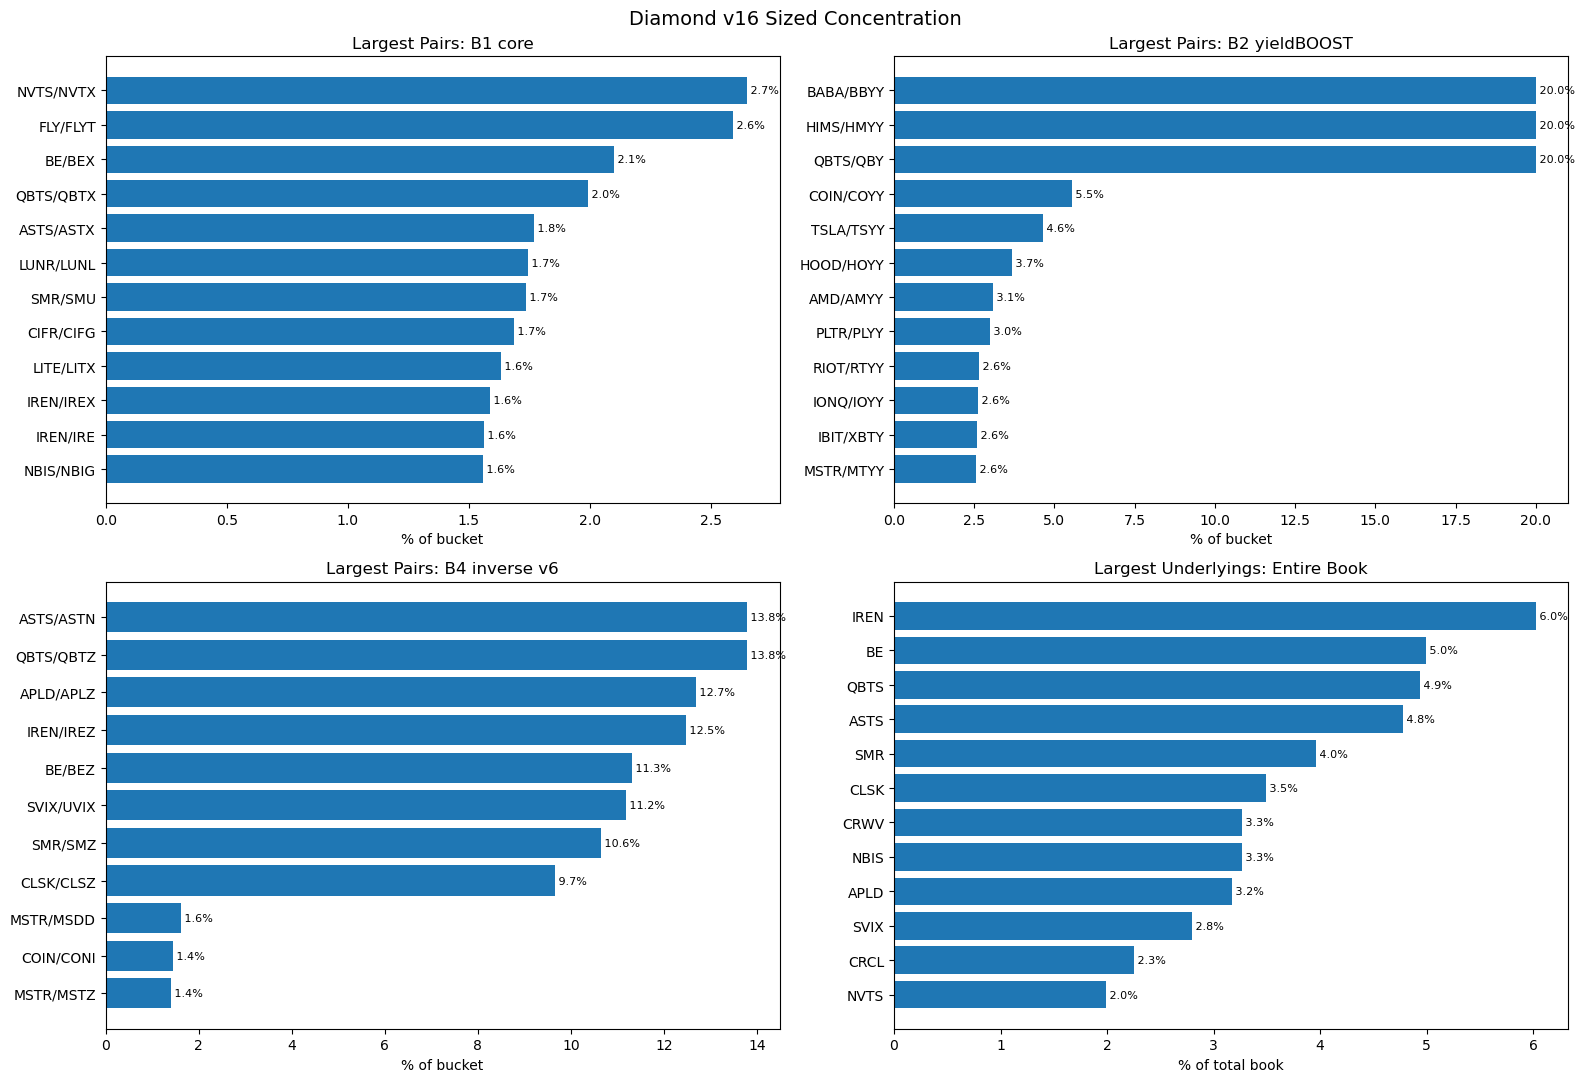

,bucket,ETF,Underlying,pair,bucket_pct,book_pct
78,B1 core,NVTX,NVTS,NVTS/NVTX,0.026523,0.019892
71,B1 core,FLYT,FLY,FLY/FLYT,0.025909,0.019432
64,B1 core,BEX,BE,BE/BEX,0.020995,0.015746
81,B1 core,QBTX,QBTS,QBTS/QBTX,0.019915,0.014936
63,B1 core,ASTX,ASTS,ASTS/ASTX,0.017703,0.013278
110,B1 core,LUNL,LUNR,LUNR/LUNL,0.017436,0.013077
84,B1 core,SMU,SMR,SMR/SMU,0.017373,0.013029
166,B1 core,CIFG,CIFR,CIFR/CIFG,0.016857,0.012643
100,B1 core,LITX,LITE,LITE/LITX,0.016331,0.012248
73,B1 core,IREX,IREN,IREN/IREX,0.015885,0.011914


,Underlying,book_pct
74,IREN,0.060249
24,BE,0.049982
121,QBTS,0.049380
17,ASTS,0.047767
138,SMR,0.039635
32,CLSK,0.034923
44,CRWV,0.032642
98,NBIS,0.032636
11,APLD,0.031722
148,SVIX,0.027969


In [263]:
# ---- Diamond v16 migration: concentration plots from sized targets ----
import matplotlib.pyplot as plt


def _bucket_pair_weights_dcq(sized_df: pd.DataFrame, bucket_label: str, bucket_book_weight: float) -> pd.DataFrame:
    if sized_df is None or sized_df.empty:
        return pd.DataFrame(columns=["bucket", "ETF", "Underlying", "pair", "bucket_pct", "book_pct"])
    d = sized_df.copy()
    d["ETF"] = d["ETF"].astype(str).map(norm_sym)
    d["Underlying"] = d["Underlying"].astype(str).map(norm_sym)
    d["gross_target_usd"] = pd.to_numeric(d.get("gross_target_usd", 0.0), errors="coerce").fillna(0.0)
    denom = float(d["gross_target_usd"].sum())
    if denom <= 0:
        return pd.DataFrame(columns=["bucket", "ETF", "Underlying", "pair", "bucket_pct", "book_pct"])
    out = d[["ETF", "Underlying", "gross_target_usd"]].copy()
    out["bucket"] = bucket_label
    out["pair"] = out["Underlying"] + "/" + out["ETF"]
    out["bucket_pct"] = out["gross_target_usd"] / denom
    out["book_pct"] = out["bucket_pct"] * float(bucket_book_weight)
    return out[["bucket", "ETF", "Underlying", "pair", "bucket_pct", "book_pct"]]


_raw_core_w = float(DCQ_BUCKET_TARGETS["core_leveraged"])
_raw_b2_w = float(DCQ_BUCKET_TARGETS["whitelist_stock"])
_raw_b4_w = float(DCQ_BUCKET_TARGETS["inverse_decay_bucket4"])
_book_den = max(_raw_core_w + _raw_b2_w + _raw_b4_w, 1e-9)
BUCKET_BOOK_WEIGHTS_DCQ = {
    "B1 core": _raw_core_w / _book_den,
    "B2 yieldBOOST": _raw_b2_w / _book_den,
    "B4 inverse v6": _raw_b4_w / _book_den,
}

CONC_PAIR_WEIGHTS_DCQ = pd.concat(
    [
        _bucket_pair_weights_dcq(B1_SIZED, "B1 core", BUCKET_BOOK_WEIGHTS_DCQ["B1 core"]),
        _bucket_pair_weights_dcq(B2_SIZED, "B2 yieldBOOST", BUCKET_BOOK_WEIGHTS_DCQ["B2 yieldBOOST"]),
        _bucket_pair_weights_dcq(B4_SIZED, "B4 inverse v6", BUCKET_BOOK_WEIGHTS_DCQ["B4 inverse v6"]),
    ],
    ignore_index=True,
)

# If the mirror B4 table is empty but v6 portfolio weights are available, use those for B4 concentration.
if (
    (CONC_PAIR_WEIGHTS_DCQ["bucket"].eq("B4 inverse v6").sum() == 0)
    and isinstance(globals().get("V6_B4_WEIGHT_OVERRIDE"), dict)
    and globals().get("V6_B4_WEIGHT_OVERRIDE")
):
    _b4_rows = []
    for (etf, und), w in globals()["V6_B4_WEIGHT_OVERRIDE"].items():
        if float(w) <= 0:
            continue
        _b4_rows.append(
            {
                "bucket": "B4 inverse v6",
                "ETF": norm_sym(etf),
                "Underlying": norm_sym(und),
                "pair": f"{norm_sym(und)}/{norm_sym(etf)}",
                "bucket_pct": float(w),
                "book_pct": float(w) * BUCKET_BOOK_WEIGHTS_DCQ["B4 inverse v6"],
            }
        )
    if _b4_rows:
        CONC_PAIR_WEIGHTS_DCQ = pd.concat([CONC_PAIR_WEIGHTS_DCQ, pd.DataFrame(_b4_rows)], ignore_index=True)

CONC_UNDERLYING_WEIGHTS_DCQ = (
    CONC_PAIR_WEIGHTS_DCQ.groupby("Underlying", as_index=False)["book_pct"]
    .sum()
    .sort_values("book_pct", ascending=False)
)

_top_n = 12
_bucket_order = ["B1 core", "B2 yieldBOOST", "B4 inverse v6"]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes_flat = axes.flatten()

for ax, bucket in zip(axes_flat[:3], _bucket_order):
    d = CONC_PAIR_WEIGHTS_DCQ[CONC_PAIR_WEIGHTS_DCQ["bucket"].eq(bucket)].nlargest(_top_n, "bucket_pct")
    if d.empty:
        ax.text(0.5, 0.5, "No sized pairs", ha="center", va="center")
        ax.set_axis_off()
        ax.set_title(bucket)
        continue
    plot_d = d.iloc[::-1]
    ax.barh(plot_d["pair"], plot_d["bucket_pct"] * 100.0)
    ax.set_title(f"Largest Pairs: {bucket}")
    ax.set_xlabel("% of bucket")
    for y, v in enumerate(plot_d["bucket_pct"] * 100.0):
        ax.text(v, y, f" {v:.1f}%", va="center", fontsize=8)

ax = axes_flat[3]
du = CONC_UNDERLYING_WEIGHTS_DCQ.nlargest(_top_n, "book_pct")
if du.empty:
    ax.text(0.5, 0.5, "No underlying weights", ha="center", va="center")
    ax.set_axis_off()
else:
    plot_du = du.iloc[::-1]
    ax.barh(plot_du["Underlying"], plot_du["book_pct"] * 100.0)
    ax.set_title("Largest Underlyings: Entire Book")
    ax.set_xlabel("% of total book")
    for y, v in enumerate(plot_du["book_pct"] * 100.0):
        ax.text(v, y, f" {v:.1f}%", va="center", fontsize=8)

fig.suptitle("Diamond v16 Sized Concentration", fontsize=14)
fig.tight_layout()
plt.show()

display(CONC_PAIR_WEIGHTS_DCQ.sort_values(["bucket", "bucket_pct"], ascending=[True, False]).groupby("bucket").head(_top_n))
display(CONC_UNDERLYING_WEIGHTS_DCQ.head(_top_n))

## Backtest Engine — v8 base engine (incremental adds, dynamic target gross)

- **Day 0:** Incumbents only, gross target **`NAV × V7_TARGET_LEV_START`** (same as a 4.5× launch book).
- **Later rebalances:** Apply **v5-style gross control**: if gross drift exceeds `gross_dead_band_pct`, run full `_apply_allocs` for all eligible pairs; otherwise beta-hedge shorts inside the dead band.
- **Post-start adds:** `_apply_one_pair` toward `tgt_gross_nav × (wcomb/Σw)` for active post-start names, with `RAMP_WEEKS` ramp-in.
- **Target gross:** `tgt_gross_nav = NAV × target_lev` with `target_lev` linear in **fraction of post-start pairs** with gross > \$1.


In [264]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)
B3_ETFS = frozenset(str(x).upper().strip().replace(".", "-") for x in (globals().get("BUCKET3_ETFS", set()) or set()))
B3_KEYS = frozenset((etf, und) for etf, und, _ in UNIVERSE if str(etf).upper().strip().replace(".", "-") in B3_ETFS)
B3_INC_KEYS = frozenset(k for k in B3_KEYS if INCEPTION[k] <= start_ts)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Bucket3 configured: {len(B3_ETFS)} ETFs | in-universe: {len(B3_KEYS)} | active at start: {len(B3_INC_KEYS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

# Reconciliation controls for matching external sheets exactly.
# Provide overrides in a prior cell, e.g.:
# EXACT_SHARE_OVERRIDES = {
#   ("NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
#   ("2026-01-02", "NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
# }
if "EXACT_SHARE_OVERRIDES" not in dir():
    EXACT_SHARE_OVERRIDES = {}

# Optional rounding mode for share conversion: "round" (default), "floor", or "ceil".
if "SHARE_ROUNDING_MODE" not in dir():
    SHARE_ROUNDING_MODE = "round"


def _shares_from_usd(usd: float, px: float, side: str) -> int:
    if px <= 0 or usd <= 0:
        return 0
    raw = usd / px
    mode = str(SHARE_ROUNDING_MODE).lower()
    if mode == "floor":
        sh = int(np.floor(raw))
    elif mode == "ceil":
        sh = int(np.ceil(raw))
    else:
        sh = int(round(raw))
    return sh if side == "long" else -sh


def _apply_exact_share_override(today, etf: str, und: str, lsh: int, ssh: int) -> tuple[int, int]:
    day_key = str(pd.Timestamp(today).date()) if today is not None else None
    ov = None
    if day_key is not None:
        ov = EXACT_SHARE_OVERRIDES.get((day_key, etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get((etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get(etf)
    if isinstance(ov, dict):
        lsh = int(ov.get("long_sh", lsh))
        ssh = int(ov.get("short_sh", ssh))
    return lsh, ssh

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}
ALL_PAIR_DAILY = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    pair_daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    # Excel-style tradeflow state by pair leg:
    # level = cumulative trade cashflow + current marked value
    pair_long_trade_cum = {}
    pair_short_trade_cum = {}
    pair_prev_long_level = {}
    pair_prev_short_level = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return abs(float(pos.get("long_sh", 0.0))) * px_map.get(
            uk, 0
        ) + abs(float(pos.get("short_sh", 0.0))) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict, today=None) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = max(abs(bv), 1e-9)
            hr = 1.0 / babs
            is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
            und_leg_usd = alloc / (1.0 + hr)
            etf_leg_usd = alloc - und_leg_usd
            if is_bucket3:
                lsh = _shares_from_usd(und_leg_usd, p_u, side="short")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
            else:
                lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
            lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict, today=None
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = max(abs(bv), 1e-9)
        hr = 1.0 / babs
        und_leg_usd = alloc_usd / (1.0 + hr)
        etf_leg_usd = alloc_usd - und_leg_usd
        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
        if is_bucket3:
            lsh = _shares_from_usd(und_leg_usd, p_u, side="short")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        else:
            lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        # Execution timing (for Excel tie-out use same-close execution).
        # - same_close: fills at today's close (default)
        # - prior_close: fills at previous close when available
        exec_timing = str(CFG.get("rebalance_execution_timing", "same_close")).strip().lower()
        if exec_timing in {"same_close", "close", "today_close"}:
            px_trade = dict(px)
        elif exec_timing in {"prior_close", "previous_close", "t_minus_1_close"}:
            px_trade = dict(prev_px) if (di > 0 and prev_px) else dict(px)
        else:
            raise ValueError(
                f"Unsupported rebalance_execution_timing={exec_timing!r}; "
                "use same_close or prior_close"
            )

        pair_day = {}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0))
            ssh = float(pos.get("short_sh", 0))
            und_long_val = max(lsh, 0.0) * px.get(uk, 0)
            und_short_val = max(-lsh, 0.0) * px.get(uk, 0)
            etf_short_val = max(-ssh, 0.0) * px.get(ek, 0)
            long_val = und_long_val
            short_val = und_short_val + etf_short_val
            pair_day[ek] = {
                "date": today,
                "etf": ek,
                "under": uk,
                "long_sh": lsh,
                "short_sh": ssh,
                "long_notional_usd": long_val,
                "short_notional_usd": short_val,
                "gross_notional_usd": long_val + short_val,
                "net_notional_usd": lsh * px.get(uk, 0) + ssh * px.get(ek, 0),
                "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                "daily_long_pnl_usd": 0.0,
                "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                "daily_short_credit_income_usd": 0.0,
                "daily_net_financing_cost_usd": 0.0,
                "daily_txn_cost_usd": 0.0,
                "daily_turnover_usd": 0.0,
            }

        daily_long_pnl = daily_short_pnl = 0.0
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0.0))
            ssh = float(pos.get("short_sh", 0.0))

            # Excel-style level method by leg:
            # level = cumulative trade cashflow + marked current value.
            long_level = float(pair_long_trade_cum.get(ek, 0.0) + lsh * px.get(uk, 0))
            short_level = float(pair_short_trade_cum.get(ek, 0.0) + ssh * px.get(ek, 0))

            prev_long_level = pair_prev_long_level.get(ek)
            prev_short_level = pair_prev_short_level.get(ek)

            if di == 0 or prev_long_level is None or prev_short_level is None:
                l_pnl = 0.0
                s_pnl = 0.0
            else:
                l_pnl = long_level - float(prev_long_level)
                s_pnl = short_level - float(prev_short_level)

            # Keep legacy MTM move for audit/debug comparison.
            if di > 0 and prev_px:
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl_mtm = lsh * dp_u if lsh > 0 else 0.0
                s_pnl_mtm = ssh * dp_e if ssh < 0 else 0.0
            else:
                l_pnl_mtm = 0.0
                s_pnl_mtm = 0.0

            pair_prev_long_level[ek] = long_level
            pair_prev_short_level[ek] = short_level

            daily_long_pnl += l_pnl
            daily_short_pnl += s_pnl
            pair_pnl[ek]["long"] += l_pnl
            pair_pnl[ek]["short"] += s_pnl

            if ek in pair_day:
                pair_day[ek]["daily_long_pnl_usd"] = float(l_pnl)
                pair_day[ek]["daily_short_pnl_usd"] = float(s_pnl)
                pair_day[ek]["daily_long_pnl_usd_mtm"] = float(l_pnl_mtm)
                pair_day[ek]["daily_short_pnl_usd_mtm"] = float(s_pnl_mtm)
                pair_day[ek]["excel_long_pnl_level_usd"] = float(long_level)
                pair_day[ek]["excel_short_pnl_level_usd"] = float(short_level)

        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short_etf = float(pos.get("short_sh", 0))
            sh_short_und = float(pos.get("long_sh", 0))
            b_etf = 0.0
            b_und = 0.0
            if sh_short_etf < 0:
                b_etf = (
                    abs(sh_short_etf)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            if sh_short_und < 0:
                und_sym = pos.get("und")
                b_und = (
                    abs(sh_short_und)
                    * px.get(und_sym, 0)
                    * BORROW_MAP.get(und_sym, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            b = float(b_etf + b_und)
            if b > 0:
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
                if ek in pair_day:
                    pair_day[ek]["daily_borrow_cost_usd"] = float(b)
                    pair_day[ek]["daily_underlying_borrow_cost_usd"] = float(b_und)
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        margin_debit_d = 0.0
        margin_credit_d = 0.0

        l_notional = sum(d["long_notional_usd"] for d in pair_day.values())
        s_notional = sum(d["short_notional_usd"] for d in pair_day.values())

        # Financing base override:
        # charge debit on full long notional minus NAV (ignore short proceeds offset).
        net_debit_balance = max(0.0, l_notional - nav)
        margin_debit_d = margin_debit_interest(
            net_debit_balance, ff, CFG["margin_debit_spreads"]
        )

        # Allocate book-level debit back to pairs for additive diagnostics.
        for ek, d in pair_day.items():
            debit_alloc = (
                margin_debit_d * (max(0.0, d["long_notional_usd"]) / l_notional)
                if l_notional > 0
                else 0.0
            )
            credit = short_credit_interest(
                max(0.0, d["short_notional_usd"]), ff, CFG["credit_spread"]
            )
            d["daily_margin_debit_cost_usd"] = float(debit_alloc)
            d["daily_short_credit_income_usd"] = float(credit)
            d["daily_net_financing_cost_usd"] = float(debit_alloc - credit)
            margin_credit_d += credit

        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)
        pair_pos_before_rebal = {
            ek: {
                "und": pos["und"],
                "long_sh": float(pos.get("long_sh", 0)),
                "short_sh": float(pos.get("short_sh", 0)),
            }
            for ek, pos in pair_pos.items()
        }

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)
            b3_active_today = sorted({e for e, _, _, _ in frac_rows if str(e).upper().strip().replace(".", "-") in B3_ETFS})
            print(f"[bucket3] universe={len(B3_KEYS)} | active_on_{today.strftime('%Y-%m-%d')}={len(b3_active_today)}")

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                abs(float(p.get("long_sh", 0))) * px.get(p["und"], 0)
                + abs(float(p.get("short_sh", 0))) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px_trade, today=today)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px_trade, today=today)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = max(abs(bv), 1e-9)
                        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS

                        if not is_bucket3:
                            l_val = max(pos["long_sh"], 0) * p_u
                            s_val = max(-pos["short_sh"], 0) * p_e
                            pair_gross = l_val + s_val
                            beta_net = l_val - babs * s_val

                            if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                                target_short_usd = l_val / babs
                                new_ssh = _shares_from_usd(target_short_usd, p_e, side="short")
                                _, new_ssh = _apply_exact_share_override(
                                    today, etf, und, pos["long_sh"], new_ssh
                                )
                                pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pair_pos[etf].get("long_sh", 0)
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf].get(
                            "short_sh", 0
                        )

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px_trade, today=today)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px_trade)
                trade_turnover += tusd
                dc += tc

            # Pair-led transaction ledger: compute turnover per pair from share deltas.
            # This intentionally ignores cross-pair netting at a symbol level.
            pair_keys = set(pair_pos_before_rebal) | set(pair_pos)
            for ek in pair_keys:
                new_pos = pair_pos.get(ek)
                old_pos = pair_pos_before_rebal.get(ek)
                und = (
                    new_pos["und"]
                    if new_pos is not None
                    else old_pos["und"]
                    if old_pos is not None
                    else None
                )
                if und is None:
                    continue
                old_l = float(old_pos.get("long_sh", 0)) if old_pos is not None else 0.0
                old_s = float(old_pos.get("short_sh", 0)) if old_pos is not None else 0.0
                new_l = float(new_pos.get("long_sh", 0)) if new_pos is not None else 0.0
                new_s = float(new_pos.get("short_sh", 0)) if new_pos is not None else 0.0
                turn_l = abs(new_l - old_l) * px_trade.get(und, 0)
                turn_s = abs(new_s - old_s) * px_trade.get(ek, 0)
                pair_turn = float(turn_l + turn_s)
                pair_tc = trade_cost(pair_turn, max(px_trade.get(und, 0), 1e-9), CFG) if pair_turn > 0 else 0.0

                # Update Excel-style cumulative trade cashflows from executed share deltas.
                # Buys consume cash (negative), sells generate cash (positive).
                long_trade_cash = -float(new_l - old_l) * px_trade.get(und, 0)
                short_trade_cash = -float(new_s - old_s) * px_trade.get(ek, 0)
                pair_long_trade_cum[ek] = float(pair_long_trade_cum.get(ek, 0.0) + long_trade_cash)
                pair_short_trade_cum[ek] = float(pair_short_trade_cum.get(ek, 0.0) + short_trade_cash)

                # Ensure newly-opened pairs on day 0 are present in pair_day so
                # entry turnover/txn costs are captured in the pair ledger.
                if ek not in pair_day and new_pos is not None:
                    lsh = float(new_pos.get("long_sh", 0.0))
                    ssh = float(new_pos.get("short_sh", 0.0))
                    und_long_val = max(lsh, 0.0) * px.get(und, 0)
                    und_short_val = max(-lsh, 0.0) * px.get(und, 0)
                    etf_short_val = max(-ssh, 0.0) * px.get(ek, 0)
                    long_val = und_long_val
                    short_val = und_short_val + etf_short_val
                    pair_day[ek] = {
                        "date": today,
                        "etf": ek,
                        "under": und,
                        "long_sh": lsh,
                        "short_sh": ssh,
                        "long_notional_usd": long_val,
                        "short_notional_usd": short_val,
                        "gross_notional_usd": long_val + short_val,
                        "net_notional_usd": lsh * px.get(und, 0) + ssh * px.get(ek, 0),
                        "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                        "daily_long_pnl_usd": 0.0,
                        "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                        "daily_short_credit_income_usd": 0.0,
                        "daily_net_financing_cost_usd": 0.0,
                        "daily_txn_cost_usd": 0.0,
                        "daily_turnover_usd": 0.0,
                    }

                if ek in pair_day:
                    pair_day[ek]["daily_turnover_usd"] = pair_turn
                    pair_day[ek]["daily_txn_cost_usd"] = float(pair_tc)
                    pair_day[ek]["excel_long_trades_usd"] = float(long_trade_cash)
                    pair_day[ek]["excel_short_trades_usd"] = float(short_trade_cash)

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            und_signed = float(pos.get("long_sh", 0.0)) * px.get(uk, 0)
            etf_signed = float(pos.get("short_sh", 0.0)) * px.get(ek, 0)
            und_abs = abs(float(pos.get("long_sh", 0.0))) * px.get(uk, 0)
            etf_abs = abs(float(pos.get("short_sh", 0.0))) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = und_signed + etf_signed
            gross_row[f"{uk}/{ek}"] = und_abs + etf_abs
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "net_debit_balance_usd": net_debit_balance,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        for ek, d in pair_day.items():
            d["fed_funds_rate"] = float(ff)
            d["is_rebal"] = int(is_rebal)
            d["daily_pair_gross_trading_pnl_usd"] = float(
                d["daily_long_pnl_usd"] + d["daily_short_pnl_usd"]
            )
            d["daily_total_cost_usd"] = float(
                d["daily_borrow_cost_usd"]
                + d["daily_net_financing_cost_usd"]
                + d["daily_txn_cost_usd"]
            )
            d["daily_pair_net_pnl_usd"] = float(
                d["daily_pair_gross_trading_pnl_usd"] - d["daily_total_cost_usd"]
            )
            pair_daily_rows.append(d)

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    pair_daily_df = pd.DataFrame(pair_daily_rows)
    if not pair_daily_df.empty:
        pair_daily_df["date"] = pd.to_datetime(pair_daily_df["date"])
        pair_daily_df = pair_daily_df.sort_values(["date", "etf"]).reset_index(drop=True)
    ALL_PAIR_DAILY[gross_lev] = pair_daily_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (net debit base): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v7 ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 148 | Rebalance days: 31 (weekly)
Pairs: 265 | Incumbents (≤ start): 165 | Post-start: 100
Bucket3 configured: 0 ETFs | in-universe: 0 | active at start: 0
Start: 2025-10-07 | End: 2026-05-08
v8 target gross multiple: 4x → 4.5x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (249 pairs, top weight: 2.65%)

  v7 RUN (store key 4.25x) | dynamic tgt gross 4x–4.5x
[bucket3] universe=0 | active_on_2025-10-07=0
  2025-10-07  NAV=$   4,958,205  Gross=$  19,998,615  L=$12,876,933  S=$ 7,121,682  Cash=$  -797,047  FF=4.09% REBAL  tgtL=4.00x
[bucket3] universe=0 | active_on_2025-10-10=0
[bucket3] universe=0 | active_on_2025-10-17=0
[bucket3] universe=0 | active_on_2025-10-24=0
[bucket3] universe=0 | active_on_2025-10-31=0
[bucket3] universe=0 | active_on_2025-11-07=0
[bucket3] universe=0 | active_on_2025-11-14=0
[bucket3] universe=0 | active_on_2025-11-21=0
[bucket3] universe=0 | active_on_2025-11-28=0
[bucket3] universe=0 |

In [265]:
# ---- Bucket 2 PnL and cost audit ----
# Run after the stock backtest cell. Gross PnL uses total-return price series, so dividends
# are already included in the MTM move; borrow and financing are separate explicit charges.
ref = max(LEVERAGE_RUNS)
PAIR_DAILY_REF = ALL_PAIR_DAILY.get(ref, pd.DataFrame()).copy()
BT_REF = ALL_BT.get(ref, pd.DataFrame()).copy()

if PAIR_DAILY_REF.empty:
    raise RuntimeError("ALL_PAIR_DAILY is empty. Run the stock backtest cell before this audit.")
if "B2_SIZED" not in globals() or B2_SIZED.empty:
    raise RuntimeError("B2_SIZED is empty. Run the Diamond sizing cell before this audit.")

_b2_etfs = set(B2_SIZED["ETF"].astype(str).map(norm_sym))
B2_PAIR_DAILY_AUDIT = PAIR_DAILY_REF[PAIR_DAILY_REF["etf"].astype(str).map(norm_sym).isin(_b2_etfs)].copy()
if B2_PAIR_DAILY_AUDIT.empty:
    raise RuntimeError("No ALL_PAIR_DAILY rows matched B2_SIZED ETFs.")

_num_cols = [
    "daily_long_pnl_usd", "daily_short_pnl_usd", "daily_long_pnl_usd_mtm", "daily_short_pnl_usd_mtm",
    "daily_pair_gross_trading_pnl_usd", "daily_borrow_cost_usd", "daily_underlying_borrow_cost_usd",
    "daily_margin_debit_cost_usd", "daily_short_credit_income_usd", "daily_net_financing_cost_usd",
    "daily_txn_cost_usd", "daily_turnover_usd", "daily_total_cost_usd", "daily_pair_net_pnl_usd",
    "long_notional_usd", "short_notional_usd", "gross_notional_usd", "net_notional_usd",
]
for _c in _num_cols:
    if _c not in B2_PAIR_DAILY_AUDIT.columns:
        B2_PAIR_DAILY_AUDIT[_c] = 0.0
    B2_PAIR_DAILY_AUDIT[_c] = pd.to_numeric(B2_PAIR_DAILY_AUDIT[_c], errors="coerce").fillna(0.0)

B2_PAIR_DAILY_AUDIT["daily_pair_gross_mtm_pnl_usd"] = (
    B2_PAIR_DAILY_AUDIT["daily_long_pnl_usd_mtm"] + B2_PAIR_DAILY_AUDIT["daily_short_pnl_usd_mtm"]
)
B2_PAIR_DAILY_AUDIT["gross_vs_mtm_diff_usd"] = (
    B2_PAIR_DAILY_AUDIT["daily_pair_gross_trading_pnl_usd"] - B2_PAIR_DAILY_AUDIT["daily_pair_gross_mtm_pnl_usd"]
)

# Actual portfolio transaction costs are paid after symbol-level netting. The pair ledger's
# daily_txn_cost_usd is useful as pair-level standalone turnover cost, but it can exceed what
# the portfolio actually pays when multiple pairs trade the same symbol in opposite directions.
_all_turnover_by_day = PAIR_DAILY_REF.groupby("date")["daily_turnover_usd"].sum().rename("all_pair_turnover_usd")
_b2_turnover_by_day = B2_PAIR_DAILY_AUDIT.groupby("date")["daily_turnover_usd"].sum().rename("b2_pair_turnover_usd")
_txn_actual_by_day = BT_REF["cum_costs"].diff().fillna(BT_REF["cum_costs"]).rename("actual_symbol_netted_txn_cost_usd")
_txn_alloc = pd.concat([_b2_turnover_by_day, _all_turnover_by_day, _txn_actual_by_day], axis=1).fillna(0.0)
_txn_alloc["b2_actual_symbol_netted_txn_cost_alloc_usd"] = np.where(
    _txn_alloc["all_pair_turnover_usd"] > 0,
    _txn_alloc["actual_symbol_netted_txn_cost_usd"] * _txn_alloc["b2_pair_turnover_usd"] / _txn_alloc["all_pair_turnover_usd"],
    0.0,
)
B2_ACTUAL_TXN_ALLOC_DAILY = _txn_alloc.reset_index()

B2_PNL_COST_SUMMARY = pd.DataFrame([
    {
        "leverage_key": ref,
        "start": pd.to_datetime(B2_PAIR_DAILY_AUDIT["date"]).min().date(),
        "end": pd.to_datetime(B2_PAIR_DAILY_AUDIT["date"]).max().date(),
        "pairs_sized": len(_b2_etfs),
        "pairs_with_ledger_rows": B2_PAIR_DAILY_AUDIT["etf"].nunique(),
        "gross_trading_pnl_usd": B2_PAIR_DAILY_AUDIT["daily_pair_gross_trading_pnl_usd"].sum(),
        "gross_mtm_audit_pnl_usd": B2_PAIR_DAILY_AUDIT["daily_pair_gross_mtm_pnl_usd"].sum(),
        "gross_vs_mtm_diff_usd": B2_PAIR_DAILY_AUDIT["gross_vs_mtm_diff_usd"].sum(),
        "gross_vs_mtm_abs_diff_usd": B2_PAIR_DAILY_AUDIT["gross_vs_mtm_diff_usd"].abs().sum(),
        "long_leg_pnl_usd": B2_PAIR_DAILY_AUDIT["daily_long_pnl_usd"].sum(),
        "short_leg_pnl_usd": B2_PAIR_DAILY_AUDIT["daily_short_pnl_usd"].sum(),
        "borrow_cost_usd": B2_PAIR_DAILY_AUDIT["daily_borrow_cost_usd"].sum(),
        "underlying_borrow_cost_usd": B2_PAIR_DAILY_AUDIT["daily_underlying_borrow_cost_usd"].sum(),
        "margin_debit_cost_usd": B2_PAIR_DAILY_AUDIT["daily_margin_debit_cost_usd"].sum(),
        "short_credit_income_usd": B2_PAIR_DAILY_AUDIT["daily_short_credit_income_usd"].sum(),
        "net_margin_financing_cost_usd": B2_PAIR_DAILY_AUDIT["daily_net_financing_cost_usd"].sum(),
        "pair_ledger_txn_cost_usd": B2_PAIR_DAILY_AUDIT["daily_txn_cost_usd"].sum(),
        "allocated_actual_symbol_netted_txn_cost_usd": B2_ACTUAL_TXN_ALLOC_DAILY["b2_actual_symbol_netted_txn_cost_alloc_usd"].sum(),
        "pair_ledger_total_cost_usd": B2_PAIR_DAILY_AUDIT["daily_total_cost_usd"].sum(),
        "pair_ledger_net_pnl_usd": B2_PAIR_DAILY_AUDIT["daily_pair_net_pnl_usd"].sum(),
        "net_pnl_with_allocated_actual_txn_usd": (
            B2_PAIR_DAILY_AUDIT["daily_pair_gross_trading_pnl_usd"].sum()
            - B2_PAIR_DAILY_AUDIT["daily_borrow_cost_usd"].sum()
            - B2_PAIR_DAILY_AUDIT["daily_net_financing_cost_usd"].sum()
            - B2_ACTUAL_TXN_ALLOC_DAILY["b2_actual_symbol_netted_txn_cost_alloc_usd"].sum()
        ),
        "turnover_usd": B2_PAIR_DAILY_AUDIT["daily_turnover_usd"].sum(),
        "avg_gross_notional_usd": B2_PAIR_DAILY_AUDIT.groupby("date")["gross_notional_usd"].sum().mean(),
        "max_gross_notional_usd": B2_PAIR_DAILY_AUDIT.groupby("date")["gross_notional_usd"].sum().max(),
    }
])

_agg_cols = [
    "daily_long_pnl_usd", "daily_short_pnl_usd", "daily_pair_gross_trading_pnl_usd",
    "daily_pair_gross_mtm_pnl_usd", "gross_vs_mtm_diff_usd", "daily_borrow_cost_usd",
    "daily_underlying_borrow_cost_usd", "daily_margin_debit_cost_usd", "daily_short_credit_income_usd",
    "daily_net_financing_cost_usd", "daily_txn_cost_usd", "daily_turnover_usd", "daily_total_cost_usd",
    "daily_pair_net_pnl_usd",
]
B2_PER_PAIR_PNL_COSTS = B2_PAIR_DAILY_AUDIT.groupby(["etf", "under"], as_index=False)[_agg_cols].sum()
_b2_exposure = B2_PAIR_DAILY_AUDIT.groupby(["etf", "under"], as_index=False).agg(
    active_days=("date", "nunique"),
    avg_gross_notional_usd=("gross_notional_usd", "mean"),
    max_gross_notional_usd=("gross_notional_usd", "max"),
    avg_borrow_rate_annual=("borrow_rate_annual", "mean"),
)
B2_PER_PAIR_PNL_COSTS = (
    B2_PER_PAIR_PNL_COSTS.merge(_b2_exposure, on=["etf", "under"], how="left")
    .sort_values("daily_pair_net_pnl_usd", ascending=False)
    .reset_index(drop=True)
)
B2_DAILY_PNL_COSTS = B2_PAIR_DAILY_AUDIT.groupby("date", as_index=False)[_agg_cols].sum().merge(
    B2_ACTUAL_TXN_ALLOC_DAILY[["date", "b2_actual_symbol_netted_txn_cost_alloc_usd"]],
    on="date",
    how="left",
)

_audit_out_dir = Path("data/runs/b2_pnl_audit")
_audit_out_dir.mkdir(parents=True, exist_ok=True)
B2_PNL_COST_SUMMARY.to_csv(_audit_out_dir / "b2_summary.csv", index=False)
B2_PER_PAIR_PNL_COSTS.to_csv(_audit_out_dir / "b2_per_pair_pnl_costs.csv", index=False)
B2_DAILY_PNL_COSTS.to_csv(_audit_out_dir / "b2_daily_pnl_costs.csv", index=False)
B2_PAIR_DAILY_AUDIT.to_csv(_audit_out_dir / "b2_pair_daily_ledger.csv", index=False)

print("Bucket 2 PnL/cost audit complete.")
print("Dividends: included in gross MTM PnL via total-return PRICES (Yahoo Adj Close or close+dividends fallback).")
print("Borrow: charged separately each day on ETF short notional; underlying borrow should be zero for B2 unless an underlying leg is short.")
print("Transaction costs: pair-ledger t-cost is shown, plus allocated actual symbol-netted t-cost paid by the portfolio.")
display(B2_PNL_COST_SUMMARY.T.rename(columns={0: "value"}))
display(B2_PER_PAIR_PNL_COSTS.head(25))
display(B2_PER_PAIR_PNL_COSTS.tail(25))

Bucket 2 PnL/cost audit complete.
Dividends: included in gross MTM PnL via total-return PRICES (Yahoo Adj Close or close+dividends fallback).
Borrow: charged separately each day on ETF short notional; underlying borrow should be zero for B2 unless an underlying leg is short.
Transaction costs: pair-ledger t-cost is shown, plus allocated actual symbol-netted t-cost paid by the portfolio.


,value
leverage_key,4.25
start,2025-10-07
end,2026-05-08
pairs_sized,16
pairs_with_ledger_rows,16
gross_trading_pnl_usd,349320.137256
gross_mtm_audit_pnl_usd,349213.808135
gross_vs_mtm_diff_usd,106.329122
gross_vs_mtm_abs_diff_usd,9077.735637
long_leg_pnl_usd,-39398.867647


,etf,under,daily_long_pnl_usd,daily_short_pnl_usd,daily_pair_gross_trading_pnl_usd,daily_pair_gross_mtm_pnl_usd,gross_vs_mtm_diff_usd,daily_borrow_cost_usd,daily_underlying_borrow_cost_usd,daily_margin_debit_cost_usd,daily_short_credit_income_usd,daily_net_financing_cost_usd,daily_txn_cost_usd,daily_turnover_usd,daily_total_cost_usd,daily_pair_net_pnl_usd,active_days,avg_gross_notional_usd,max_gross_notional_usd,avg_borrow_rate_annual
0,HMYY,HIMS,1171.110415,47597.396849,48768.507263,48612.323248,156.184015,403.865406,0.0,146.923208,0.0,146.923208,470.803302,221087.402975,1021.591915,47746.915348,106,85712.281349,110370.556177,0.014372
1,MTYY,MSTR,-15281.398773,64302.803017,49021.404243,49195.793236,-174.388992,3357.318663,0.0,291.822498,0.0,291.822498,489.387114,242818.312195,4138.528275,44882.875968,148,98062.330019,137760.753056,0.080703
2,COYY,COIN,-17870.288071,54213.799997,36343.511926,34955.596464,1387.915462,5574.915840,0.0,320.177000,0.0,320.177000,483.720008,240347.642273,6378.812848,29964.699078,148,99379.666633,142315.622572,0.136388
3,MAAY,MARA,3736.459201,27730.961648,31467.420850,31516.137158,-48.716309,989.901595,0.0,191.540218,0.0,191.540218,480.783128,206648.108441,1662.224940,29805.195910,125,88303.724720,105410.149214,0.029577
4,IOYY,IONQ,5675.970942,18898.548526,24574.519467,24650.364995,-75.845528,704.494329,0.0,199.738034,0.0,199.738034,451.987374,217310.837363,1356.219737,23218.299730,125,88875.476541,110306.672712,0.021144
5,QBY,QBTS,420.609972,23515.844099,23936.454071,24203.194786,-266.740715,1669.741246,0.0,149.311979,0.0,149.311979,406.445395,188852.401462,2225.498619,21710.955452,106,86146.898316,108267.345623,0.059308
6,HOYY,HOOD,-17499.388420,47106.073250,29606.684830,28477.994889,1128.689941,7449.899459,0.0,325.875915,0.0,325.875915,514.850653,253449.766490,8290.626027,21316.058803,148,99682.011570,143887.674454,0.182775
7,FBYY,META,-1039.060486,19305.951530,18266.891045,18076.081095,190.809950,0.000000,0.0,315.442223,0.0,315.442223,426.634381,212739.797744,742.076604,17524.814441,135,90569.950114,109073.464722,-0.011772
8,XBTY,IBIT,-15255.597961,31803.360205,16547.762243,15566.384598,981.377645,270.379341,0.0,379.059113,0.0,379.059113,428.404848,207973.645102,1077.843302,15469.918941,148,99939.628116,139736.222470,0.007101
9,TSYY,TSLA,-369.639709,14547.055152,14177.415443,13699.298707,478.116736,518.664599,0.0,400.402899,0.0,400.402899,428.599192,213422.834972,1347.666690,12829.748753,148,104125.368751,146938.736561,0.013164


,etf,under,daily_long_pnl_usd,daily_short_pnl_usd,daily_pair_gross_trading_pnl_usd,daily_pair_gross_mtm_pnl_usd,gross_vs_mtm_diff_usd,daily_borrow_cost_usd,daily_underlying_borrow_cost_usd,daily_margin_debit_cost_usd,daily_short_credit_income_usd,daily_net_financing_cost_usd,daily_txn_cost_usd,daily_turnover_usd,daily_total_cost_usd,daily_pair_net_pnl_usd,active_days,avg_gross_notional_usd,max_gross_notional_usd,avg_borrow_rate_annual
0,HMYY,HIMS,1171.110415,47597.396849,48768.507263,48612.323248,156.184015,403.865406,0.0,146.923208,0.0,146.923208,470.803302,221087.402975,1021.591915,47746.915348,106,85712.281349,110370.556177,0.014372
1,MTYY,MSTR,-15281.398773,64302.803017,49021.404243,49195.793236,-174.388992,3357.318663,0.0,291.822498,0.0,291.822498,489.387114,242818.312195,4138.528275,44882.875968,148,98062.330019,137760.753056,0.080703
2,COYY,COIN,-17870.288071,54213.799997,36343.511926,34955.596464,1387.915462,5574.915840,0.0,320.177000,0.0,320.177000,483.720008,240347.642273,6378.812848,29964.699078,148,99379.666633,142315.622572,0.136388
3,MAAY,MARA,3736.459201,27730.961648,31467.420850,31516.137158,-48.716309,989.901595,0.0,191.540218,0.0,191.540218,480.783128,206648.108441,1662.224940,29805.195910,125,88303.724720,105410.149214,0.029577
4,IOYY,IONQ,5675.970942,18898.548526,24574.519467,24650.364995,-75.845528,704.494329,0.0,199.738034,0.0,199.738034,451.987374,217310.837363,1356.219737,23218.299730,125,88875.476541,110306.672712,0.021144
5,QBY,QBTS,420.609972,23515.844099,23936.454071,24203.194786,-266.740715,1669.741246,0.0,149.311979,0.0,149.311979,406.445395,188852.401462,2225.498619,21710.955452,106,86146.898316,108267.345623,0.059308
6,HOYY,HOOD,-17499.388420,47106.073250,29606.684830,28477.994889,1128.689941,7449.899459,0.0,325.875915,0.0,325.875915,514.850653,253449.766490,8290.626027,21316.058803,148,99682.011570,143887.674454,0.182775
7,FBYY,META,-1039.060486,19305.951530,18266.891045,18076.081095,190.809950,0.000000,0.0,315.442223,0.0,315.442223,426.634381,212739.797744,742.076604,17524.814441,135,90569.950114,109073.464722,-0.011772
8,XBTY,IBIT,-15255.597961,31803.360205,16547.762243,15566.384598,981.377645,270.379341,0.0,379.059113,0.0,379.059113,428.404848,207973.645102,1077.843302,15469.918941,148,99939.628116,139736.222470,0.007101
9,TSYY,TSLA,-369.639709,14547.055152,14177.415443,13699.298707,478.116736,518.664599,0.0,400.402899,0.0,400.402899,428.599192,213422.834972,1347.666690,12829.748753,148,104125.368751,146938.736561,0.013164


In [266]:
# ---- Diamond v16 migration: Bucket 4 v6 aggregation + combined sleeve NAV ----
B4_BT_DCQ = pd.DataFrame()
B4_BY_PAIR_DCQ = {}
COMBINED_DCQ_BT = pd.DataFrame()

if not V6_GLOBALS_READY:
    print("[DCQ B4] Skipped: v6 globals/cache unavailable.")
else:
    B4_V6_WEIGHT_OVERRIDE, B4_V6_DIAG, B4_V6_META = compute_b4_v6_override(SELECTED_B4_PARAMS)
    if not B4_V6_WEIGHT_OVERRIDE:
        print("[DCQ B4] Skipped: v6 weight override produced no eligible pairs.")
    else:
        _b4_pf_params = V6PfParams(
            **{k: v for k, v in _v6_pf_param_dict_dcq(SELECTED_B4_PARAMS).items() if k in V6PfParams.__dataclass_fields__}
        )
        _b4_start = pd.Timestamp(B4_V6_META.get("start_sim")) if B4_V6_META.get("start_sim") is not None else None
        if _b4_start is None:
            _b4_start = min(
                pd.Timestamp(c["prices"].index[0])
                for k, c in globals()["_V6_PAIR_CACHE"].items()
                if k in B4_V6_WEIGHT_OVERRIDE and isinstance(c.get("prices"), pd.DataFrame) and not c["prices"].empty
            )
        B4_BT_DCQ, B4_BY_PAIR_DCQ = aggregate_tail_risk_weighted_portfolio(
            globals()["_V6_PAIR_CACHE"],
            globals()["v6_opt2_h_daily_map"],
            pd.DatetimeIndex(globals()["v6_opt2_rebal_index"]),
            B4_V6_WEIGHT_OVERRIDE,
            start_sim=_b4_start,
            pf_initial=float(CFG["capital_usd"]),
            opt2_h_base=float(globals()["V6_OPT2_H_BASE"]),
            get_ibkr_borrow_map=_v6_backtest_borrow_map_dcq,
            norm_sym=norm_sym,
            use_ibkr_uvix_borrow=bool(EXP.get("b4_weights_use_ibkr_uvix_borrow", True)),
        )
        print(
            f"[DCQ B4] v6 pairs={len(B4_V6_WEIGHT_OVERRIDE)} | backtested={len(B4_BY_PAIR_DCQ)} | "
            f"start={pd.Timestamp(_b4_start).date()} | decay={B4_V6_META.get('decay_src_col')}"
        )

if ALL_BT:
    _stock_key = next(iter(ALL_BT.keys()))
    STOCK_BT_DCQ = ALL_BT[_stock_key].copy()
    _stock_nav = pd.to_numeric(STOCK_BT_DCQ.get("NAV", STOCK_BT_DCQ.get("nav")), errors="coerce").dropna()
    if _stock_nav.empty:
        print("[DCQ combined] Skipped: stock backtest has no NAV column.")
    else:
        _raw_core = float(DCQ_BUCKET_TARGETS["core_leveraged"])
        _raw_b2 = float(DCQ_BUCKET_TARGETS["whitelist_stock"])
        _raw_b4 = float(DCQ_BUCKET_TARGETS["inverse_decay_bucket4"]) if not B4_BT_DCQ.empty else 0.0
        _den = max(_raw_core + _raw_b2 + _raw_b4, 1e-9)
        _stock_w = (_raw_core + _raw_b2) / _den
        _b4_w = _raw_b4 / _den

        if not B4_BT_DCQ.empty:
            _b4_nav = pd.to_numeric(B4_BT_DCQ.get("equity", B4_BT_DCQ.get("nav")), errors="coerce").dropna()
            _idx = pd.DatetimeIndex(sorted(set(_stock_nav.index) | set(_b4_nav.index)))
            _stock_norm = _stock_nav.reindex(_idx).ffill().bfill() / float(_stock_nav.iloc[0])
            _b4_norm = _b4_nav.reindex(_idx).ffill().fillna(float(_b4_nav.iloc[0])) / float(_b4_nav.iloc[0])
            _combined_nav = float(CFG["capital_usd"]) * (_stock_w * _stock_norm + _b4_w * _b4_norm)
        else:
            _idx = pd.DatetimeIndex(_stock_nav.index)
            _combined_nav = float(CFG["capital_usd"]) * (_stock_nav / float(_stock_nav.iloc[0]))

        COMBINED_DCQ_BT = pd.DataFrame(index=_idx)
        COMBINED_DCQ_BT["nav"] = _combined_nav.astype(float)
        COMBINED_DCQ_BT["ret"] = COMBINED_DCQ_BT["nav"].pct_change().fillna(0.0)
        COMBINED_DCQ_BT["drawdown"] = COMBINED_DCQ_BT["nav"] / COMBINED_DCQ_BT["nav"].cummax() - 1.0
        COMBINED_DCQ_BT.attrs["stock_weight"] = float(_stock_w)
        COMBINED_DCQ_BT.attrs["b4_weight"] = float(_b4_w)
        print(
            f"[DCQ combined] stock_key={_stock_key} | stock_weight={_stock_w:.1%} | b4_weight={_b4_w:.1%} | "
            f"NAV ${COMBINED_DCQ_BT['nav'].iloc[0]:,.0f} -> ${COMBINED_DCQ_BT['nav'].iloc[-1]:,.0f}"
        )
else:
    print("[DCQ combined] Run the stock backtest engine cell before this B4/combined cell.")

[DCQ B4] v6 pairs=11 | backtested=11 | start=2025-10-07 | decay=net_edge_p50_annual
[DCQ combined] stock_key=4.25 | stock_weight=75.0% | b4_weight=25.0% | NAV $5,000,000 -> $9,350,089


In [267]:
# ---- Per-pair end-of-backtest PnL by bucket ----
# B1/B2 are simulated in the stock engine; B4 is a separate v6 sleeve and then blended into COMBINED_DCQ_BT.
ref = max(LEVERAGE_RUNS)
_stock_pair_daily = ALL_PAIR_DAILY.get(ref, pd.DataFrame()).copy()

if _stock_pair_daily.empty:
    raise RuntimeError("ALL_PAIR_DAILY is empty. Run the stock backtest cell before this per-pair PnL summary.")

_stock_w = float(getattr(COMBINED_DCQ_BT, "attrs", {}).get("stock_weight", 1.0)) if "COMBINED_DCQ_BT" in globals() else 1.0
_b4_w = float(getattr(COMBINED_DCQ_BT, "attrs", {}).get("b4_weight", 0.0)) if "COMBINED_DCQ_BT" in globals() else 0.0

_bucket_map_rows = []
for _bucket, _df in [("B1 core", B1_SIZED), ("B2 yieldBOOST", B2_SIZED)]:
    if _df is None or _df.empty:
        continue
    for _, _r in _df.iterrows():
        _bucket_map_rows.append({
            "etf": norm_sym(_r["ETF"]),
            "under": norm_sym(_r["Underlying"]),
            "bucket": _bucket,
        })
_BUCKET_MAP_DCQ = pd.DataFrame(_bucket_map_rows).drop_duplicates(["etf", "under"])

_stock_pair_daily["etf"] = _stock_pair_daily["etf"].map(norm_sym)
_stock_pair_daily["under"] = _stock_pair_daily["under"].map(norm_sym)
_num_cols = [
    "daily_long_pnl_usd", "daily_short_pnl_usd", "daily_pair_gross_trading_pnl_usd",
    "daily_borrow_cost_usd", "daily_underlying_borrow_cost_usd", "daily_margin_debit_cost_usd",
    "daily_short_credit_income_usd", "daily_net_financing_cost_usd", "daily_txn_cost_usd",
    "daily_total_cost_usd", "daily_pair_net_pnl_usd", "daily_turnover_usd",
    "long_notional_usd", "short_notional_usd", "gross_notional_usd", "net_notional_usd",
]
for _c in _num_cols:
    if _c not in _stock_pair_daily.columns:
        _stock_pair_daily[_c] = 0.0
    _stock_pair_daily[_c] = pd.to_numeric(_stock_pair_daily[_c], errors="coerce").fillna(0.0)

_stock_agg = _stock_pair_daily.groupby(["etf", "under"], as_index=False).agg(
    active_days=("date", "nunique"),
    start_date=("date", "min"),
    end_date=("date", "max"),
    long_pnl_usd=("daily_long_pnl_usd", "sum"),
    short_pnl_usd=("daily_short_pnl_usd", "sum"),
    gross_trading_pnl_usd=("daily_pair_gross_trading_pnl_usd", "sum"),
    borrow_cost_usd=("daily_borrow_cost_usd", "sum"),
    underlying_borrow_cost_usd=("daily_underlying_borrow_cost_usd", "sum"),
    margin_debit_cost_usd=("daily_margin_debit_cost_usd", "sum"),
    short_credit_income_usd=("daily_short_credit_income_usd", "sum"),
    net_financing_cost_usd=("daily_net_financing_cost_usd", "sum"),
    txn_cost_usd=("daily_txn_cost_usd", "sum"),
    total_cost_usd=("daily_total_cost_usd", "sum"),
    net_pnl_usd=("daily_pair_net_pnl_usd", "sum"),
    turnover_usd=("daily_turnover_usd", "sum"),
    avg_gross_notional_usd=("gross_notional_usd", "mean"),
    max_gross_notional_usd=("gross_notional_usd", "max"),
)
_stock_last = (
    _stock_pair_daily.sort_values("date")
    .groupby(["etf", "under"], as_index=False)
    .tail(1)[["etf", "under", "long_notional_usd", "short_notional_usd", "gross_notional_usd", "net_notional_usd"]]
    .rename(columns={
        "long_notional_usd": "ending_long_notional_usd",
        "short_notional_usd": "ending_short_notional_usd",
        "gross_notional_usd": "ending_gross_notional_usd",
        "net_notional_usd": "ending_net_notional_usd",
    })
)
_stock_rows = (
    _stock_agg.merge(_stock_last, on=["etf", "under"], how="left")
    .merge(_BUCKET_MAP_DCQ, on=["etf", "under"], how="left")
)
_stock_rows["bucket"] = _stock_rows["bucket"].fillna("B1/B2 stock engine")
_stock_rows["sleeve_local_initial_capital_usd"] = np.nan
_stock_rows["sleeve_local_return"] = np.nan
_stock_rows["combined_portfolio_weight"] = _stock_w
_stock_rows["combined_portfolio_pnl_usd"] = _stock_rows["net_pnl_usd"] * _stock_w
_stock_rows["combined_portfolio_pnl_pct_initial_nav"] = _stock_rows["combined_portfolio_pnl_usd"] / float(CFG["capital_usd"])

_b4_rows = []
if "B4_BY_PAIR_DCQ" in globals() and isinstance(B4_BY_PAIR_DCQ, dict) and B4_BY_PAIR_DCQ:
    _b4_weights = globals().get("B4_V6_WEIGHT_OVERRIDE", {}) or globals().get("V6_B4_WEIGHT_OVERRIDE", {}) or {}
    for (_etf, _under), _bt in B4_BY_PAIR_DCQ.items():
        if _bt is None or _bt.empty:
            continue
        _etf_n, _under_n = norm_sym(_etf), norm_sym(_under)
        _w_pair = float(_b4_weights.get((_etf_n, _under_n), _b4_weights.get((_etf, _under), np.nan)))
        _initial_cap = float(_w_pair * CFG["capital_usd"]) if np.isfinite(_w_pair) else float(_bt["equity"].iloc[0])
        _final_equity = float(pd.to_numeric(_bt["equity"], errors="coerce").dropna().iloc[-1])
        _borrow = float(pd.to_numeric(_bt.get("borrow_cost", 0.0), errors="coerce").fillna(0.0).sum())
        _short_credit = float(pd.to_numeric(_bt.get("short_proceeds_credit", 0.0), errors="coerce").fillna(0.0).sum())
        _net_financing_cost = _borrow - _short_credit
        _txn = float(pd.to_numeric(_bt.get("rebalance_fee", 0.0), errors="coerce").fillna(0.0).sum())
        _net_pnl = _final_equity - _initial_cap
        _gross_trading = _net_pnl + _net_financing_cost + _txn
        _last = _bt.iloc[-1]
        _a_notional = float(_last.get("a_shares", 0.0)) * float(_last.get("a_px", 0.0))
        _b_notional = float(_last.get("b_shares", 0.0)) * float(_last.get("b_px", 0.0))
        _ending_gross = abs(_a_notional) + abs(_b_notional)
        _b4_rows.append({
            "etf": _etf_n,
            "under": _under_n,
            "active_days": int(len(_bt)),
            "start_date": _bt.index.min(),
            "end_date": _bt.index.max(),
            "long_pnl_usd": 0.0,
            "short_pnl_usd": np.nan,
            "gross_trading_pnl_usd": _gross_trading,
            "borrow_cost_usd": _borrow,
            "underlying_borrow_cost_usd": np.nan,
            "margin_debit_cost_usd": 0.0,
            "short_credit_income_usd": _short_credit,
            "net_financing_cost_usd": _net_financing_cost,
            "txn_cost_usd": _txn,
            "total_cost_usd": _net_financing_cost + _txn,
            "net_pnl_usd": _net_pnl,
            "turnover_usd": np.nan,
            "avg_gross_notional_usd": np.nan,
            "max_gross_notional_usd": np.nan,
            "ending_long_notional_usd": 0.0,
            "ending_short_notional_usd": _ending_gross,
            "ending_gross_notional_usd": _ending_gross,
            "ending_net_notional_usd": _a_notional + _b_notional,
            "bucket": "B4 inverse v6",
            "sleeve_local_initial_capital_usd": _initial_cap,
            "sleeve_local_return": _net_pnl / _initial_cap if _initial_cap else np.nan,
            "combined_portfolio_weight": _b4_w,
            "combined_portfolio_pnl_usd": _net_pnl * _b4_w,
            "combined_portfolio_pnl_pct_initial_nav": (_net_pnl * _b4_w) / float(CFG["capital_usd"]),
        })
_b4_df = pd.DataFrame(_b4_rows)

_PER_PAIR_COLS = [
    "bucket", "etf", "under", "active_days", "start_date", "end_date",
    "gross_trading_pnl_usd", "borrow_cost_usd", "underlying_borrow_cost_usd",
    "margin_debit_cost_usd", "short_credit_income_usd", "net_financing_cost_usd",
    "txn_cost_usd", "total_cost_usd", "net_pnl_usd", "combined_portfolio_pnl_usd",
    "combined_portfolio_pnl_pct_initial_nav", "sleeve_local_initial_capital_usd", "sleeve_local_return",
    "ending_long_notional_usd", "ending_short_notional_usd", "ending_gross_notional_usd", "ending_net_notional_usd",
    "avg_gross_notional_usd", "max_gross_notional_usd", "turnover_usd", "long_pnl_usd", "short_pnl_usd",
]
PER_PAIR_PNL_BY_BUCKET_DCQ = pd.concat([_stock_rows, _b4_df], ignore_index=True, sort=False)
PER_PAIR_PNL_BY_BUCKET_DCQ = PER_PAIR_PNL_BY_BUCKET_DCQ[_PER_PAIR_COLS].sort_values(
    ["bucket", "combined_portfolio_pnl_usd"], ascending=[True, False]
).reset_index(drop=True)

BUCKET_PNL_SUMMARY_DCQ = PER_PAIR_PNL_BY_BUCKET_DCQ.groupby("bucket", as_index=False).agg(
    pairs=("etf", "nunique"),
    gross_trading_pnl_usd=("gross_trading_pnl_usd", "sum"),
    borrow_cost_usd=("borrow_cost_usd", "sum"),
    net_financing_cost_usd=("net_financing_cost_usd", "sum"),
    txn_cost_usd=("txn_cost_usd", "sum"),
    total_cost_usd=("total_cost_usd", "sum"),
    net_pnl_usd=("net_pnl_usd", "sum"),
    combined_portfolio_pnl_usd=("combined_portfolio_pnl_usd", "sum"),
    combined_portfolio_pnl_pct_initial_nav=("combined_portfolio_pnl_pct_initial_nav", "sum"),
)

_pair_out_dir = Path("data/runs/per_pair_pnl_by_bucket")
_pair_out_dir.mkdir(parents=True, exist_ok=True)
PER_PAIR_PNL_BY_BUCKET_DCQ.to_csv(_pair_out_dir / "per_pair_end_pnl_by_bucket.csv", index=False)
BUCKET_PNL_SUMMARY_DCQ.to_csv(_pair_out_dir / "bucket_end_pnl_summary.csv", index=False)

print(f"Per-pair PnL by bucket complete: {len(PER_PAIR_PNL_BY_BUCKET_DCQ)} pairs")
print(f"Stock contribution scale={_stock_w:.1%}; B4 contribution scale={_b4_w:.1%}")
print(f"Saved to {_pair_out_dir.resolve()}")
display(BUCKET_PNL_SUMMARY_DCQ)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 240):
    display(PER_PAIR_PNL_BY_BUCKET_DCQ)

Per-pair PnL by bucket complete: 276 pairs
Stock contribution scale=75.0%; B4 contribution scale=25.0%
Saved to C:\Users\werdn\Documents\Investing\ls-algo\notebooks\data\runs\per_pair_pnl_by_bucket


,bucket,pairs,gross_trading_pnl_usd,borrow_cost_usd,net_financing_cost_usd,txn_cost_usd,total_cost_usd,net_pnl_usd,combined_portfolio_pnl_usd,combined_portfolio_pnl_pct_initial_nav
0,B1 core,249,1.348124e+06,358371.592313,161713.470499,200236.564283,720321.627095,627802.589441,470851.942081,0.094170
1,B2 yieldBOOST,16,3.493201e+05,36650.707313,4533.510446,7584.991300,48769.209059,300550.928197,225413.196148,0.045083
2,B4 inverse v6,11,1.062873e+06,324399.622874,324399.622874,26797.512336,351197.135210,711675.730787,177918.932697,0.035584


,bucket,etf,under,active_days,start_date,end_date,gross_trading_pnl_usd,borrow_cost_usd,underlying_borrow_cost_usd,margin_debit_cost_usd,short_credit_income_usd,net_financing_cost_usd,txn_cost_usd,total_cost_usd,net_pnl_usd,combined_portfolio_pnl_usd,combined_portfolio_pnl_pct_initial_nav,sleeve_local_initial_capital_usd,sleeve_local_return,ending_long_notional_usd,ending_short_notional_usd,ending_gross_notional_usd,ending_net_notional_usd,avg_gross_notional_usd,max_gross_notional_usd,turnover_usd,long_pnl_usd,short_pnl_usd
0,B1 core,ASTX,ASTS,148,2025-10-07,2026-05-08,70601.858423,4409.623212,0.0,3718.102498,0.0,3718.102498,4292.698301,12420.424012,58181.434411,43636.075808,8.727215e-03,NaN,NaN,252393.160263,127569.257050,379962.417313,124823.903214,506883.422029,8.683118e+05,2.100253e+06,43455.592018,27146.266405
1,B1 core,QBTX,QBTS,148,2025-10-07,2026-05-08,48584.530606,3406.631138,0.0,4030.299159,0.0,4030.299159,5036.054385,12472.984682,36111.545925,27083.659443,5.416732e-03,NaN,NaN,335886.735458,181677.067434,517563.802893,154209.668024,550966.965114,1.001724e+06,2.353280e+06,-88648.573513,137233.104119
2,B1 core,LUNL,LUNR,78,2026-01-16,2026-05-08,49905.501659,14689.878781,0.0,1525.309396,0.0,1525.309396,2443.385416,18658.573593,31246.928066,23435.196050,4.687039e-03,NaN,NaN,325043.392296,175036.500000,500079.892296,150006.892296,396966.966616,6.459852e+05,1.126423e+06,143336.164185,-93430.662525
3,B1 core,OKLL,OKLO,148,2025-10-07,2026-05-08,45178.649258,9619.310509,0.0,2940.171173,0.0,2940.171173,3143.012450,15702.494132,29476.155126,22107.116345,4.421423e-03,NaN,NaN,260020.867661,126137.000000,386157.867661,133883.867661,398884.556214,7.338383e+05,1.541559e+06,-142166.177059,187344.826317
4,B1 core,BMNU,BMNR,148,2025-10-07,2026-05-08,42704.036211,9724.385033,0.0,2318.835057,0.0,2318.835057,2777.981171,14821.201261,27882.834950,20912.126212,4.182425e-03,NaN,NaN,190262.940655,93874.436145,284137.376800,96388.504510,314530.997690,4.579516e+05,1.317959e+06,-197769.232346,240473.268556
5,B1 core,BMNG,BMNR,130,2025-10-31,2026-05-08,36924.081144,6686.947671,0.0,2158.819788,0.0,2158.819788,2989.091452,11834.858912,25089.222232,18816.916674,3.763383e-03,NaN,NaN,236465.220814,118992.721893,355457.942707,117472.498920,334758.529913,5.331523e+05,1.405708e+06,-78419.153240,115343.234385
6,B1 core,UUUG,UUUU,78,2026-01-16,2026-05-08,27330.282110,673.259384,0.0,1338.224031,0.0,1338.224031,1570.848823,3582.332239,23747.949871,17810.962404,3.562192e-03,NaN,NaN,248628.010241,119810.041424,368438.051664,128817.968817,349030.880358,4.495056e+05,7.247496e+05,-11068.151413,38398.433523
7,B1 core,FLYT,FLY,135,2025-10-24,2026-05-08,40414.625858,6170.827387,0.0,4203.812825,0.0,4203.812825,7428.664135,17803.304348,22611.321510,16958.491133,3.391698e-03,NaN,NaN,501158.403854,277961.185055,779119.588909,223197.218800,631413.704363,9.874868e+05,3.473758e+06,349778.677565,-309364.051706
8,B1 core,IRE,IREN,135,2025-10-24,2026-05-08,37766.378542,11665.700265,0.0,2560.535516,0.0,2560.535516,3884.167164,18110.402945,19655.975597,14741.981698,2.948396e-03,NaN,NaN,345535.204308,222932.891712,568468.096020,122602.312595,385611.894425,5.684681e+05,1.874126e+06,61801.786320,-24035.407778
9,B1 core,CIFG,CIFR,101,2025-12-12,2026-05-08,28928.576408,4437.242694,0.0,1981.851820,0.0,1981.851820,3157.379314,9576.473828,19352.102580,14514.076935,2.902815e-03,NaN,NaN,335108.837559,192539.529531,527648.367089,142569.308028,401588.631673,5.938650e+05,1.426320e+06,113488.457081,-84559.880673


In [268]:
def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1/ny) - 1
    vol = r.std() * (TRADING_DAYS**0.5)
    sr = cagr / vol if vol > 0 else 0
    neg = r[r < 0]
    dv = neg.std() * (TRADING_DAYS**0.5)
    sortino = cagr / dv if dv > 0 else 0
    dd = (nav - nav.cummax()) / nav.cummax()
    calmar = cagr / abs(dd.min()) if dd.min() < 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Sortino": sortino,
            "Max DD": dd.min(), "Calmar": calmar, "Monthly Win%": (mo > 0).mean(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}

## Performance — Diamond Creek Fund weighted


In [269]:
ref = max(LEVERAGE_RUNS)

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  v8 Diamond Creek Fund — {lev}x (store key)")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Short Credit':<20s}: ${bt['cum_margin_credit'].iloc[-1]:>14,.0f}")
    print(
        f"  {'Net Financing':<20s}: "
        f"${(bt['cum_margin_debit'].iloc[-1] + bt['cum_borrow'].iloc[-1] - bt['cum_margin_credit'].iloc[-1]):>14,.0f}"
    )
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")



  v8 Diamond Creek Fund — 4.25x (store key)
  CAGR                :         35.79%
  Vol                 :         11.39%
  Sharpe              :        314.17%
  Sortino             :        468.35%
  Max DD              :         -4.33%
  Calmar              :        826.68%
  Monthly Win%        :          71.4%
  Final NAV           : $     5,934,081
  P&L                 : $       975,877
  Txn Costs           : $       209,670
  Borrow Costs        : $       395,022
  Margin Debit        : $       166,247
  Short Credit        : $             0
  Net Financing       : $       561,269
  Long P&L            : $     1,190,481
  Short P&L           : $       506,963


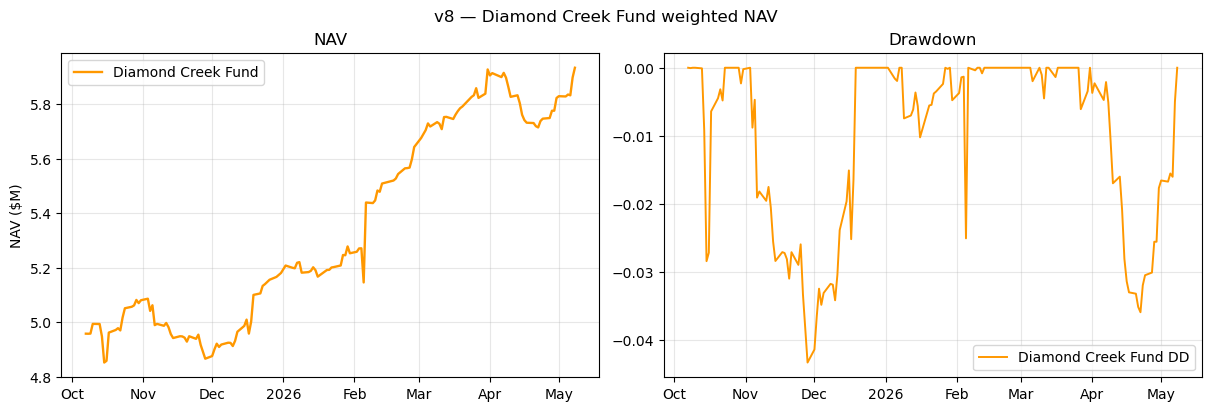

In [270]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.suptitle("v8 — Diamond Creek Fund weighted NAV")

dc_nav = ALL_BT[ref]["nav"]
ax = axes[0]
ax.plot(dc_nav.index, dc_nav / 1e6, label="Diamond Creek Fund", color="#FF9800", lw=1.7)
ax.set_ylabel("NAV ($M)")
ax.set_title("NAV")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
dd_dc = (dc_nav - dc_nav.cummax()) / dc_nav.cummax()
ax.plot(dd_dc.index, dd_dc, label="Diamond Creek Fund DD", color="#FF9800", lw=1.4)
ax.set_title("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


## NAV Jump Attribution (Diamond Creek Fund)

Ranks the largest absolute daily NAV moves and estimates top pair-level contributors on those days using lagged pair gross and pair spread returns.


In [271]:
ref = max(LEVERAGE_RUNS)

if "UNIVERSE" not in globals() or len(UNIVERSE) == 0:
    if "CANDIDATES" in globals() and "INCEPTION" in globals():
        UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
        UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
        print(f"[UNIVERSE] Rebuilt from CANDIDATES+INCEPTION: {len(UNIVERSE)} pairs")
    else:
        raise RuntimeError("Run universe setup cells first: CANDIDATES + INCEPTION/UNIVERSE are missing.")

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2026-02-06  NAV ret=+5.70%  NAV pnl=$+293,317
2026-02-05  NAV ret=-2.38%  NAV pnl=$-125,316
2025-10-17  NAV ret=+2.13%  NAV pnl=$+103,639
2025-12-19  NAV ret=+1.95%  NAV pnl=$+97,777
2025-10-15  NAV ret=-1.94%  NAV pnl=$-95,807
2026-03-31  NAV ret=+1.52%  NAV pnl=$+88,947
2025-11-06  NAV ret=-1.44%  NAV pnl=$-73,064
2026-05-07  NAV ret=+1.12%  NAV pnl=$+65,248

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2026-02-06  NAV ret=+5.70%  NAV pnl=$+293,317
         KEEX/KEEL  contrib=$+4,479
         MSTR/MTYY  contrib=$+2,948
         IBIT/XBTY  contrib=$+2,630
         NVTS/NVTX  contrib=$-2,159
         MARA/MAAY  contrib=$+2,053

2026-02-05  NAV ret=-2.38%  NAV pnl=$-125,316
         KEEX/KEEL  contrib=$-3,814
         NVTS/NVTX  contrib=$+2,298
         IBIT/XBTY  contrib=$-2,249
         HIMS/HMYY  contrib=$+1,655

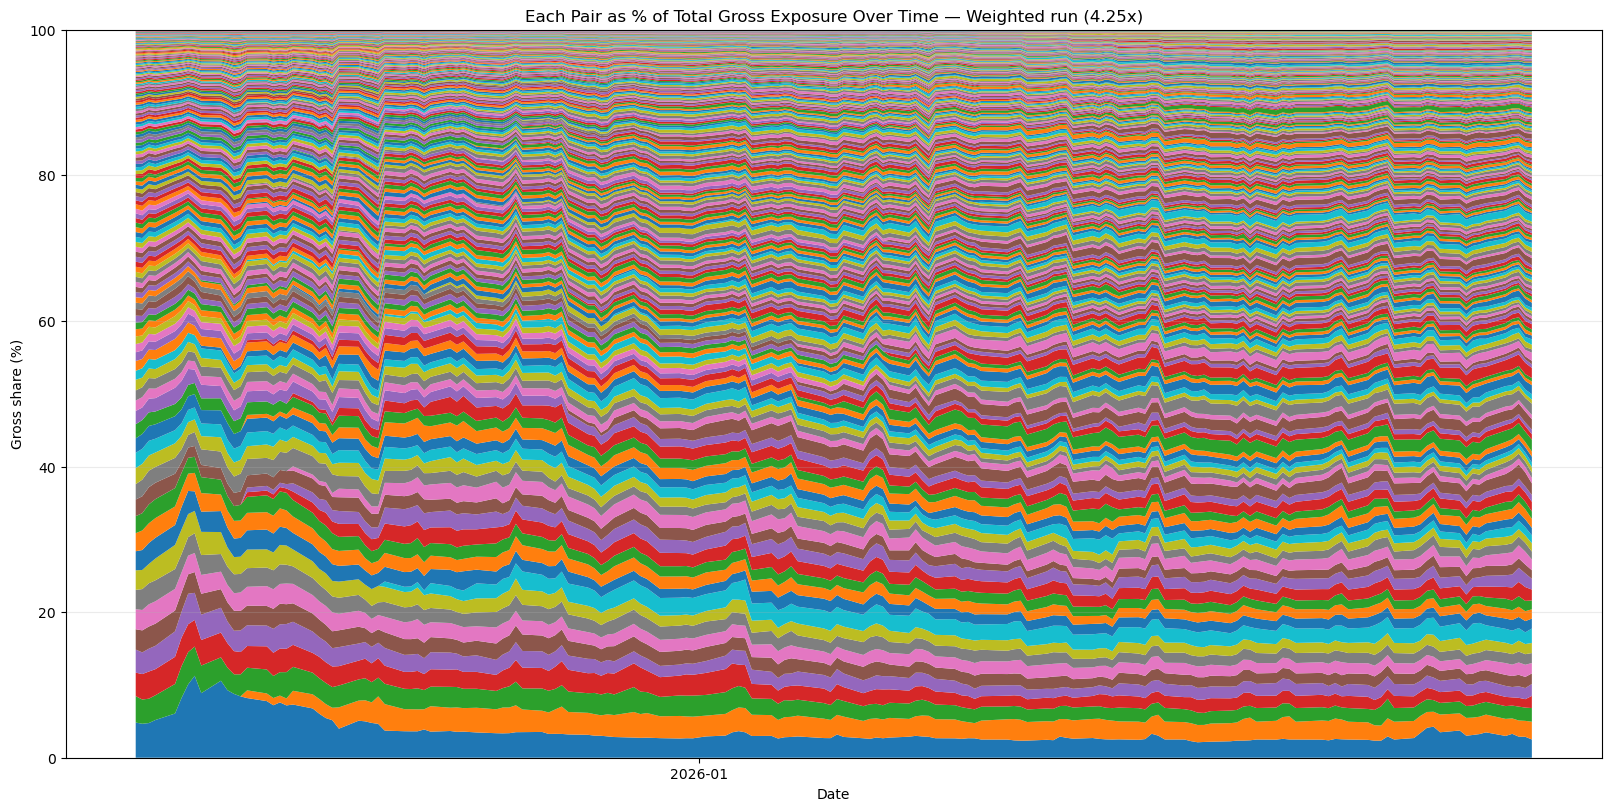

Pairs plotted: 265 | Date range: 2025-10-07 -> 2026-05-08
Top 15 pairs by average gross share (%):


,avg_gross_share_pct
NVTS/NVTX,3.649186
FLY/FLYT,2.424964
QBTS/QBTX,2.392436
ASTS/ASTX,2.204720
SMR/SMU,1.973275
CRWV/CRWG,1.857351
NBIS/NEBX,1.833647
CRWV/CRWU,1.763335
OKLO/OKLL,1.736541
BE/BEX,1.714860


In [272]:
# ---- Pair gross share over time (% of total gross; each pair) ----
# Uses the most recent weighted run by default.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    run_label = f"Weighted run ({ref_lev}x)"
elif "EW_PAIR_GROSS" in globals() and isinstance(EW_PAIR_GROSS, dict) and len(EW_PAIR_GROSS) > 0:
    ref_lev = max(EW_PAIR_GROSS)
    gross_df = EW_PAIR_GROSS[ref_lev].copy()
    run_label = f"Equal-weight run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross time series found. Run a backtest cell first.")

if gross_df is None or gross_df.empty:
    raise RuntimeError("Pair gross time series is empty.")

# Ensure datetime index + numeric matrix.
gross_df = gross_df.copy()
gross_df.index = pd.to_datetime(gross_df.index)
gross_df = gross_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# % share of total gross exposure each day.
total_gross = gross_df.sum(axis=1).replace(0.0, np.nan)
pair_gross_pct = gross_df.div(total_gross, axis=0).fillna(0.0) * 100.0

# Sort pairs for a stable stacked ordering (largest average share at bottom).
pair_order = pair_gross_pct.mean(axis=0).sort_values(ascending=False).index.tolist()
pair_gross_pct = pair_gross_pct[pair_order]

fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
ax.stackplot(pair_gross_pct.index, pair_gross_pct.T.values, linewidth=0)
ax.set_title(f"Each Pair as % of Total Gross Exposure Over Time — {run_label}")
ax.set_ylabel("Gross share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Pairs plotted: {pair_gross_pct.shape[1]} | Date range: {pair_gross_pct.index.min().date()} -> {pair_gross_pct.index.max().date()}")
print("Top 15 pairs by average gross share (%):")
display(pair_gross_pct.mean().sort_values(ascending=False).head(15).to_frame("avg_gross_share_pct"))

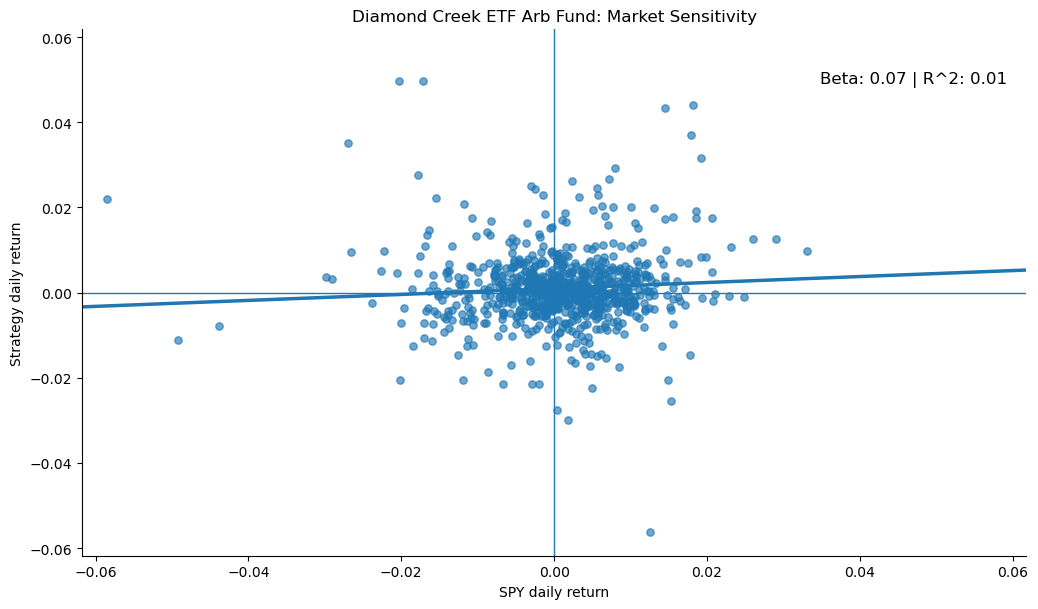

{'beta': 0.07001643839063522, 'r2': 0.006209160196898433, 'r2_corr_check': 0.006209160196898203, 'r2_abs_diff': 2.3071822230491534e-16, 'n_obs': 813}
R^2 cross-check passed (OLS score ~= corr^2 for single-factor regression).


In [273]:
# ---- V11 scatter: strategy daily returns vs SPY (beta + R^2) ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression


def _to_date_index(s: pd.Series) -> pd.Series:
    s = s.copy()
    idx = pd.to_datetime(s.index)
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    idx = idx.normalize()
    s.index = idx
    s = s[~s.index.duplicated(keep="last")]
    return s.sort_index()


def load_adjclose_returns(ticker: str, start: str) -> pd.Series:
    df = yf.download(
        ticker,
        start=start,
        auto_adjust=False,
        progress=False,
        threads=False,
        timeout=30,
    )
    if df is None or df.empty:
        return pd.Series(dtype=float, name=ticker)

    col = "Adj Close" if "Adj Close" in df.columns else "Close"
    px = df[col]
    if isinstance(px, pd.DataFrame):
        px = px.iloc[:, 0]
    px = px.dropna().astype(float)
    px.index = pd.to_datetime(px.index).tz_localize(None)

    ret = px.pct_change().dropna()
    ret.name = ticker
    return _to_date_index(ret)


def plot_spy_scatter_with_beta_r2(
    port_ret: pd.Series,
    start: str | None = "2023-01-01",
    end: str | None = "2026-03-31",
    title: str = "Diamond Creek ETF Arb Fund: Market Sensitivity",
    spy_ret_external: pd.Series | None = None,
):
    y = port_ret.replace([np.inf, -np.inf], np.nan).dropna()
    if start is not None:
        y = y.loc[pd.Timestamp(start):]
    if end is not None:
        y = y.loc[:pd.Timestamp(end)]
    y = _to_date_index(y)

    if spy_ret_external is not None:
        spy = _to_date_index(spy_ret_external)
        if start is not None:
            spy = spy.loc[pd.Timestamp(start):]
        if end is not None:
            spy = spy.loc[:pd.Timestamp(end)]
    else:
        spy = load_adjclose_returns("SPY", start=str(y.index.min().date()))
        if end is not None:
            spy = spy.loc[:pd.Timestamp(end)]
        spy = _to_date_index(spy)

    df = pd.concat([spy.rename("SPY"), y.rename("STRAT")], axis=1).dropna()
    if len(df) < 50:
        raise ValueError(f"Not enough overlapping observations: {len(df)}")

    x = df[["SPY"]].to_numpy()
    yv = df["STRAT"].to_numpy()

    lr = LinearRegression(fit_intercept=True)
    lr.fit(x, yv)

    beta = float(lr.coef_[0])
    r2 = float(lr.score(x, yv))
    corr = float(df[["SPY", "STRAT"]].corr().iloc[0, 1])
    r2_corr = corr**2

    # Display scaling only: widen x-axis so fit line appears less steep visually.
    x_abs = float(np.nanmax(np.abs(df["SPY"].to_numpy())))
    y_abs = float(np.nanmax(np.abs(df["STRAT"].to_numpy())))
    x_lim = max(0.01, 1.35 * x_abs)
    y_lim = max(0.01, 1.10 * y_abs)

    x_line = np.linspace(-x_lim, x_lim, 300).reshape(-1, 1)
    y_line = lr.predict(x_line)

    plt.figure(figsize=(10.5, 6.2))
    plt.scatter(df["SPY"], df["STRAT"], alpha=0.65, s=28)
    plt.plot(x_line.flatten(), y_line, linewidth=2.5)

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlim(-y_lim, y_lim)
    plt.ylim(-y_lim, y_lim)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.title(title)
    plt.xlabel("SPY daily return")
    plt.ylabel("Strategy daily return")

    plt.text(
        0.98,
        0.92,
        f"Beta: {beta:.2f} | R^2: {r2:.2f}",
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        fontsize=12,
    )

    plt.tight_layout()
    plt.savefig("diamond_creek_spy_scatter_v11.svg", format="svg", bbox_inches="tight")
    plt.show()
    return {
        "beta": beta,
        "r2": r2,
        "r2_corr_check": r2_corr,
        "r2_abs_diff": abs(r2 - r2_corr),
        "n_obs": int(len(df)),
    }


# Prefer net-to-LP series for market-sensitivity reporting.
if "dc_net_ret" in globals():
    _port_ret_for_scatter = dc_net_ret.copy()
elif "dc_gross_ret" in globals():
    _port_ret_for_scatter = dc_gross_ret.copy()
else:
    raise RuntimeError("Run the v11 performance cell first so dc_net_ret or dc_gross_ret exists.")

_spy_ret_for_scatter = spy_ret.copy() if "spy_ret" in globals() else None

scatter_stats = plot_spy_scatter_with_beta_r2(
    _port_ret_for_scatter,
    start="2023-01-01",
    end="2026-03-31",
    title="Diamond Creek ETF Arb Fund: Market Sensitivity",
    spy_ret_external=_spy_ret_for_scatter,
)
print(scatter_stats)

if scatter_stats["r2_abs_diff"] > 1e-10:
    print(f"[WARN] R^2 cross-check diff is non-trivial: {scatter_stats['r2_abs_diff']:.3e}")
else:
    print("R^2 cross-check passed (OLS score ~= corr^2 for single-factor regression).")

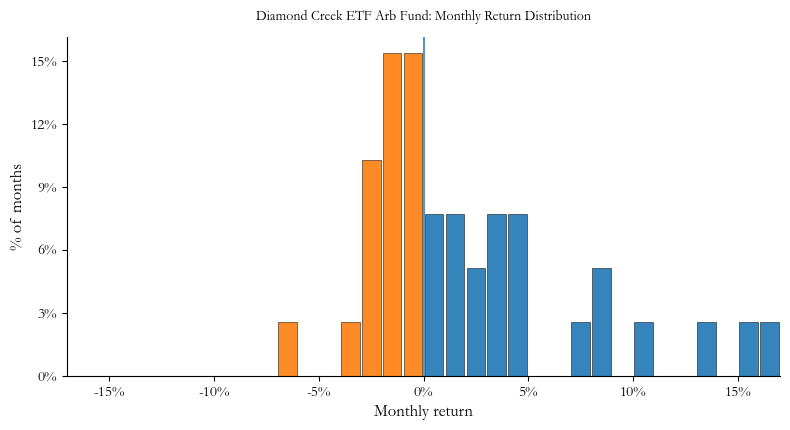

{'n_months': 39, 'mean_monthly': 0.0216350395187007, 'median_monthly': 0.003281194082142669, 'pct_positive_months': 0.5384615384615384, 'worst_month': -0.06218756471767406, 'best_month': 0.16071322120498466}


In [274]:
# ---- V11 monthly return distribution ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import font_manager as fm
from matplotlib.ticker import FuncFormatter, MaxNLocator


def plot_monthly_return_distribution_clean(
    port_ret_daily: pd.Series,
    title: str = "Diamond Creek ETF Arb Fund: Monthly Return Distribution",
    bin_width: float = 0.01,
    xlim: float = 0.06,
    show_mean: bool = False,
    start: str | None = "2023-01-01",
    end: str | None = "2026-03-31",
    font_family: str = "Garamond",
    savepath: str | None = None,
):
    r = port_ret_daily.replace([np.inf, -np.inf], np.nan).dropna().copy()
    r.index = pd.to_datetime(r.index)
    if getattr(r.index, "tz", None) is not None:
        r.index = r.index.tz_convert("UTC").tz_localize(None)
    r.index = r.index.normalize()

    if start is not None:
        r = r.loc[pd.Timestamp(start):]
    if end is not None:
        r = r.loc[:pd.Timestamp(end)]

    monthly = (1.0 + r).resample("M").prod() - 1.0
    monthly = monthly.dropna()

    monthly_plot = monthly[np.abs(monthly) <= xlim]

    bins = np.arange(-xlim, xlim + bin_width, bin_width)
    counts, edges = np.histogram(monthly_plot, bins=bins)
    pct = counts / counts.sum() * 100 if counts.sum() > 0 else np.zeros_like(counts, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])

    pct_fmt = FuncFormatter(lambda y, _: f"{y:.0f}%")
    ret_fmt = FuncFormatter(lambda x, _: f"{100 * x:.0f}%")

    # Lock font for PPT consistency.
    font_prop = None
    _font_candidates = [
        Path(f"C:/Windows/Fonts/{str(font_family).lower()}.ttf"),
        Path(f"C:/Windows/Fonts/{str(font_family).lower()}.ttc"),
        Path("C:/Windows/Fonts/garamond.ttf"),
        Path("C:/Windows/Fonts/garamond.ttc"),
        Path("C:/Windows/Fonts/gara.ttf"),
        Path("C:/Windows/Fonts/garabd.ttf"),
        Path("C:/Windows/Fonts/cambria.ttc"),
        Path("C:/Windows/Fonts/calibri.ttf"),
    ]
    _font_path = next((p for p in _font_candidates if p.exists()), None)
    if _font_path is not None:
        font_prop = fm.FontProperties(fname=str(_font_path))
    else:
        plt.rcParams["font.family"] = font_family
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    pos_color = "#1f77b4"
    neg_color = "#ff7f0e"
    bar_colors = [neg_color if c < 0 else pos_color for c in centers]
    ax.bar(
        centers,
        pct,
        width=bin_width * 0.9,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.9,
    )

    ax.axvline(0, linewidth=1.1)
    if show_mean:
        ax.axvline(monthly.mean(), linestyle="--", linewidth=1)

    if font_prop is not None:
        ax.set_title(title, fontsize=14, pad=12, fontproperties=font_prop)
        ax.set_xlabel("Monthly return", fontsize=12, fontproperties=font_prop)
        ax.set_ylabel("% of months", fontsize=12, fontproperties=font_prop)
        for _lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            _lbl.set_fontproperties(font_prop)
    else:
        ax.set_title(title, fontsize=14, pad=12)
        ax.set_xlabel("Monthly return", fontsize=12)
        ax.set_ylabel("% of months", fontsize=12)

    ax.set_xlim(-xlim, xlim)
    ax.xaxis.set_major_formatter(ret_fmt)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.tick_params(axis="both", labelsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    fig.savefig("monthly_return_distribution_v11.svg", format="svg", bbox_inches="tight")

    plt.show()

    return {
        "n_months": int(len(monthly)),
        "mean_monthly": float(monthly.mean()) if len(monthly) else np.nan,
        "median_monthly": float(monthly.median()) if len(monthly) else np.nan,
        "pct_positive_months": float((monthly > 0).mean()) if len(monthly) else np.nan,
        "worst_month": float(monthly.min()) if len(monthly) else np.nan,
        "best_month": float(monthly.max()) if len(monthly) else np.nan,
    }


if "dc_net_ret" in globals():
    _port_ret_for_monthly = dc_net_ret.copy()
elif "dc_gross_ret" in globals():
    _port_ret_for_monthly = dc_gross_ret.copy()
else:
    raise RuntimeError("Run the v11 performance cell first so dc_net_ret or dc_gross_ret exists.")

monthly_stats = plot_monthly_return_distribution_clean(
    _port_ret_for_monthly,
    bin_width=0.01,
    xlim=0.17,
    start="2023-01-01",
    end="2026-03-31",
    savepath="monthly_return_distribution_v11.png",
)
print(monthly_stats)

In [275]:
# ---- Bucket3 target sensitivity (0%, 2%, 5%, 10%) ----
# Run this AFTER the base v15 setup cells have been executed.

import json
from pathlib import Path

nb_path = Path("notebooks/Diamond_Creek_Backtest_v15.ipynb")
if not nb_path.exists():
    nb_path = Path("Diamond_Creek_Backtest_v15.ipynb")
if not nb_path.exists():
    raise FileNotFoundError("Could not locate Diamond_Creek_Backtest_v15.ipynb")

with nb_path.open("r", encoding="utf-8") as f:
    nb_obj = json.load(f)

def _find_code_cell(substr: str) -> str:
    for c in nb_obj.get("cells", []):
        if c.get("cell_type") != "code":
            continue
        src = c.get("source", [])
        code = "".join(src) if isinstance(src, list) else str(src)
        if substr in code:
            return code
    raise RuntimeError(f"Could not find code cell containing: {substr!r}")

optimizer_code = _find_code_cell("# ---- Sample-book optimizer: PnL/Gross + NET Decay + Shares Cap ----")
runner_code = _find_code_cell("# ---- Re-run weighted backtest now (using newly built PnL/Gross weights) ----")

targets = [0.00, 0.02, 0.05, 0.10]
rows = []
_b3_etfs = {str(x).upper().strip().replace('.', '-') for x in (globals().get("BUCKET3_ETFS", set()) or set())}

for t in targets:
    BUCKET3_BUCKET_TARGET = float(t)
    exec(optimizer_code, globals(), globals())
    exec(runner_code, globals(), globals())

    lev = max(LEVERAGE_RUNS)
    bt = ALL_BT[lev]
    p = perf(bt["nav"])

    _w = w_df.copy()
    _w["etf"] = _w["etf"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
    _w["weight"] = pd.to_numeric(_w["weight"], errors="coerce").fillna(0.0)
    b3_real = float(_w.loc[_w["etf"].isin(_b3_etfs), "weight"].sum())

    rows.append({
        "bucket3_target": t,
        "bucket3_realized_weight": b3_real,
        "CAGR": float(p["CAGR"]),
        "Vol": float(p["Vol"]),
        "Sharpe": float(p["Sharpe"]),
        "MaxDD": float(p["Max DD"]),
        "Final NAV": float(p["Final NAV"]),
        "PnL": float(p["P&L"]),
        "Txn": float(bt["cum_costs"].iloc[-1]),
        "Borrow": float(bt["cum_borrow"].iloc[-1]),
        "Long P&L": float(bt["cum_long_pnl"].iloc[-1]),
        "Short P&L": float(bt["cum_short_pnl"].iloc[-1]),
    })

sens_df = pd.DataFrame(rows).sort_values("bucket3_target").reset_index(drop=True)
out_path = Path("data/backtest/v15_bucket3_sensitivity.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
sens_df.to_csv(out_path, index=False)

print("Saved:", out_path)
print(sens_df.to_string(index=False))

Equal-weight v8 NAV series saved.
[weights] Cap-override ETFs missing Supply in etfs2.csv: ['CWY', 'MUYY']
[weights] Supply override source: C:\Users\werdn\Downloads\etfs2.csv | cap-overridden tickers: 9 | bucket3 overridden: 0
[weights] Optimizer universe: 226/265 ETFs (core beta>1.5+borrow=217, whitelist=9, bucket3=0)
[weights] Sleeve targets -> core: 90.0%, whitelist: 10.0%, bucket3: 0.0%
[weights] Final sleeve realized -> core: 95.4%, whitelist: 4.6%, bucket3: 0.0% | whitelist non-zero: 9 | bucket3 non-zero: 0
[weights] Whitelist non-zero tickers: ['COYY', 'FBYY', 'HMYY', 'IOYY', 'MAAY', 'MTYY', 'QBY', 'SMYY', 'XBTY']
Using screener: C:\Users\werdn\Documents\Investing\Diamond-Creek-Quant\data\runs\2026-04-15\etf_screened_today.csv
Shares-average history root: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Signal: [net pnl/gross - max_dd_penalty * max_dd_to_gross] + (gross_decay - avg_borrow) | decay column: net_decay_annual | mix_decay_weight=0.40 | weight_power=1.15 | decay_